In [ ]:
import pandas as pd
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.6/50.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.3/141.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.7/413.7 kB 23.6 MB/s eta 0:00:00


In [ ]:
url='https://raw.githubusercontent.com/wyeekong/IRR//d0bba7d747922e59efd49cd9b0b356a43b8490a9/test_df2.7z'

In [ ]:
import requests
import py7zr
import os

token = '<REDACTED_GH_TOKEN>'
headers = {'Authorization': f'token {token}'}
response = requests.get(url, headers=headers)
if response.status_code == 200:
    # Save the file locally
    with open('file.7z', 'wb') as file:
        file.write(response.content)
    print("Download completed successfully")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")


Download completed successfully


In [1]:
import pandas as pd
csv_file_path = '/content/drive/MyDrive/IRR/test_df4.csv'
df = pd.read_csv(csv_file_path)
print(df.head())


       id_x  user_id  problem_id  topic_id                     created_at  \
0  43804593    99146     4961872      1251  2021-05-07 19:14:00.540411+00   
1  43804615    99146     4959768      1251  2021-05-07 19:14:06.501294+00   
2  43805697    60983     4970635      1251  2021-05-07 19:18:27.117183+00   
3  43805732    60983     4961410      1251  2021-05-07 19:18:34.588146+00   
4  43805808    60983     4972034      1251  2021-05-07 19:18:52.368308+00   

                      updated_at            problem_appeared_at  \
0  2021-05-07 19:14:00.540411+00  2021-05-07 19:13:56.931999+00   
1  2021-05-07 19:14:06.501294+00      2021-05-07 19:14:04.03+00   
2  2021-05-07 19:18:27.117183+00     2021-05-07 19:18:22.262+00   
3  2021-05-07 19:18:34.588146+00     2021-05-07 19:18:28.141+00   
4  2021-05-07 19:18:52.368308+00     2021-05-07 19:18:47.312+00   

           response_submitted_at  duration answerChoiceIds  ... lrdaaccuracy  \
0  2021-05-07 19:14:00.339999+00       NaN      {18682

In [ ]:
print(df.columns)

Index(['id_x', 'user_id', 'problem_id', 'topic_id', 'created_at', 'updated_at',
       'problem_appeared_at', 'response_submitted_at', 'duration',
       'answerChoiceIds', 'title', 'free', 'passed', 'score', 'qscore',
       'contest_id', 'mission_id', 'Case ID', 'Origin_x', 'matchfile', 'main',
       'sub', 'leaf', 'filename3', 'max_column', 'findgs', 'Origin_y',
       'Correct Label', 'goldstandardnew', 'id_y', 'preferred_specialty',
       'experience_level', 'GPDaccuracy', 'LPDaccuracy', 'grdaaccuracy',
       'lrdaaccuracy', 'otheraccuracy', 'seizureaccuracy', 'GPD_accuracy',
       'LPD_accuracy', 'LRDA_accuracy', 'GRDA_accuracy', 'SEIZURE_accuracy',
       'OTHER_accuracy', 'combined_accuracy'],
      dtype='object')


In [ ]:
pd.set_option('display.max_colwidth', None)

# Print out the entire content of the column 'columnmatchfile'
print(df['matchfile'].head().to_string())
pd.reset_option('display.max_colwidth')

0    https://centaur-customer-uploads.s3.us-east-1.amazonaws.com/mgh-eeg/GRDA/pat1273_20111026_174800_3128.png
1      https://centaur-customer-uploads.s3.us-east-1.amazonaws.com/mgh-eeg/GPD/sid205_20151007_214907_7692.png
2    https://centaur-customer-uploads.s3.us-east-1.amazonaws.com/mgh-eeg/LRDA/sid1025_20170605_030417_1244.png
3    https://centaur-customer-uploads.s3.us-east-1.amazonaws.com/mgh-eeg/GRDA/pat1081_20140119_152040_2211.png
4     https://centaur-customer-uploads.s3.us-east-1.amazonaws.com/mgh-eeg/LRDA/sid1025_20170605_065455_184.png


In [ ]:
unique_values = df['matchfile'].unique()

# Create a DataFrame from these unique values
unique_df = pd.DataFrame(unique_values, columns=['matchfile'])

# Save the unique values to a CSV file
unique_df.to_csv('unique_matchfile.csv', index=False)

In [ ]:
unique_values = df['matchfile'].unique()
print("Number of unique values:", len(unique_values))

Number of unique values: 8894


In [2]:
# for countries of origin run locally
import pandas as pd
df_a= df
df_b=pd.read_csv('/content/drive/MyDrive/IRR/eeg-all-users-and-topics.csv')

# Merge DataFrame B's column C into DataFrame A based on common value (A in B and E in A)
df_a = pd.merge(df_a, df_b[['id', 'locale']], left_on='user_id', right_on='id', how='left')

# Drop the redundant column created during merging
df_a.drop(columns=['id'], inplace=True)

df_a = df_a.drop_duplicates(subset=['user_id'])
unique_values = df_a['locale'].unique()
print(f"Unique values in column C: {unique_values}")

# Count the missing values in column C
missing_values_count = df_a['locale'].isnull().sum()
print(f"Number of missing values in column C: {missing_values_count}")

# Group by column C and count unique values of column A
unique_values_per_C = df_a.groupby('locale')['user_id'].nunique().reset_index()

# Rename the columns for clarity
unique_values_per_C.columns = ['locale', 'user_id']

# Display the result
#print(unique_values_per_C)

sorted_df = unique_values_per_C.sort_values(by='user_id', ascending=False)
print(sorted_df)

Unique values in column C: [nan 'en_US' 'en_PH' 'en_PT' 'en_EG' 'en_IN' 'en_ID' 'en_GH' 'en_GB'
 'en_AU' 'en_MY' 'en_AS' 'en_GE' 'en_HU' 'en_JO' 'en_KR' 'en_TW'
 'en_SA@calendar=gregorian' 'en_CH' 'en_MX' 'en_ES' 'en' 'en_HK' 'en_RO'
 'en_CO' 'en_NP' 'en_AO' 'en_AF@calendar=gregorian' 'en_CY' 'en_CR'
 'en_LT' 'en_IT' 'en_LV' 'en_LB' 'en_CA' 'en_CZ' 'en_ZA' 'en_NG' 'en_HR'
 'en_KZ' 'en_PK' 'en_BH']
Number of missing values in column C: 1271
                      locale  user_id
33                     en_PH      130
39                     en_US       61
40                     en_ZA       10
16                     en_GH        9
21                     en_IN        6
14                     en_GB        6
30                     en_MY        4
12                     en_EG        3
6                      en_CA        3
19                     en_HU        2
24                     en_KR        2
36                     en_RO        2
34                     en_PK        2
20                     e

In [ ]:
min_value = df['combinedaccuracy'].min()
max_value = df['combinedaccuracy'].max()
print("Range of combinedaccuracy:", min_value, "to", max_value)

Range of combinedaccuracy: 0.6666666666666666 to 0.9166666666666666


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = df.dropna(subset=['user_id', 'problem_id', 'title', 'goldstandardnew','experience_level'])
df.rename(columns={'combined_accuracy': 'combinedaccuracy'}, inplace=True)
#df['combinedaccuracy']=df[['GPDaccuracy','LPDaccuracy','grdaaccuracy','lrdaaccuracy','otheraccuracy','seizureaccuracy']].mean(axis=1)
#df = df.dropna(subset=['combinedaccuracy'])
file_path = '/content/drive/MyDrive/Colab Notebooks/goldstandardnew925nonandropna.csv'
#df.to_csv(file_path, index=False)


In [5]:
import pandas as pd

# Filter for experts and get unique user_ids.
expert_users = df[df['experience_level'] == 'Expert'][['user_id']].drop_duplicates()

# Merge expert_users with df_b to obtain additional columns (id, email, first, last, app_display_name)
matched_df = pd.merge(expert_users, df_b[['id', 'email', 'first', 'last', 'app_display_name']],
                      left_on='user_id', right_on='id', how='inner')

# Select only the relevant columns.
result = matched_df[['user_id', 'email', 'first', 'last', 'app_display_name']]
print(result)



   user_id                                email       first      last  \
0    41816                <REDACTED_EMAIL>  M. Brandon  Westover   
1   123180                     <REDACTED_EMAIL>         NaN       NaN   
2   129198  <REDACTED_EMAIL>       Fabio     Silva   
3   129995              <REDACTED_EMAIL>         NaN       NaN   
4   130067                  <REDACTED_EMAIL>      Masoom     desai   
5   129968                   <REDACTED_EMAIL>         NaN       NaN   
6   130226                 <REDACTED_EMAIL>         NaN       NaN   
7   130262               <REDACTED_EMAIL>    Jong Woo       Lee   

    app_display_name  
0                 bw  
1                 JJ  
2               fabs  
3  Andres Rodriguez   
4       Masoom desai  
5    Gregory Kapinos  
6       Aaron Struck  
7   Jong Woo Lee, MD  


Table 1


In [ ]:
import pandas as pd

df = df.dropna(subset=['user_id', 'problem_id', 'title', 'goldstandardnew','experience_level'])
# Group by experience_level to get the unique user count and total questions answered
experience_summary = df.groupby('experience_level').agg(
    unique_users=('user_id', 'nunique'),
    total_questions_answered=('title', 'count')
).reset_index()

# Display the results
print(experience_summary)

total_unique_users = experience_summary['unique_users'].sum()
total_questions_answered = experience_summary['total_questions_answered'].sum()


print(f"Total Unique Users Across All Experience Levels: {total_unique_users}")
print(f"Total Questions Answered Across All Experience Levels: {total_questions_answered}")

pattern_counts = df['goldstandardnew'].value_counts().reset_index()

# Rename columns for clarity
pattern_counts.columns = ['Pattern', 'Count']
pattern_counts['Percentage'] = (pattern_counts['Count'] / pattern_counts['Count'].sum()) * 100

print(pattern_counts)
print(f"Sum of Counts in pattern_counts: {pattern_counts['Count'].sum()}")

            experience_level  unique_users  total_questions_answered
0                         DO             4                       196
1                     Expert             8                      8433
2                         MD            73                     55829
3            Medical Student           538                    249827
4                         NP            45                     10185
5                 NP Student            38                      2003
6                      Other           480                     95555
7   Other Healthcare Student           321                     49367
8                         PA             7                      1909
9                 PA Student             5                       725
10                Pharmacist             9                       866
11          Pharmacy Student            14                      3939
Total Unique Users Across All Experience Levels: 1542
Total Questions Answered Across All Experience Le

Figure 2

<ipython-input-14-86d900031c26>:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_overall_WM = df.groupby(['problem_id', 'group']).apply(
<ipython-input-14-86d900031c26>:73: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_pattern_WM = df.groupby(['problem_id', 'group', 'goldstandardnew'], observed=True).apply(
<ipython-input-14-86d900031c26>:93: FutureWarning: The default of observed=False is deprecat

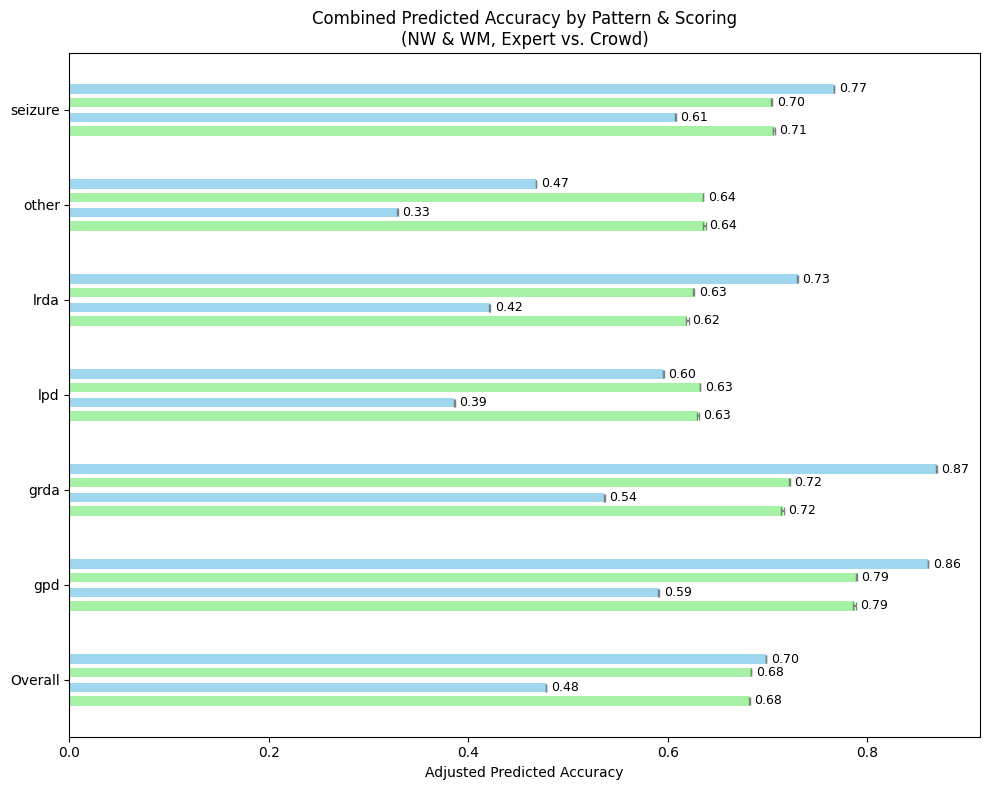

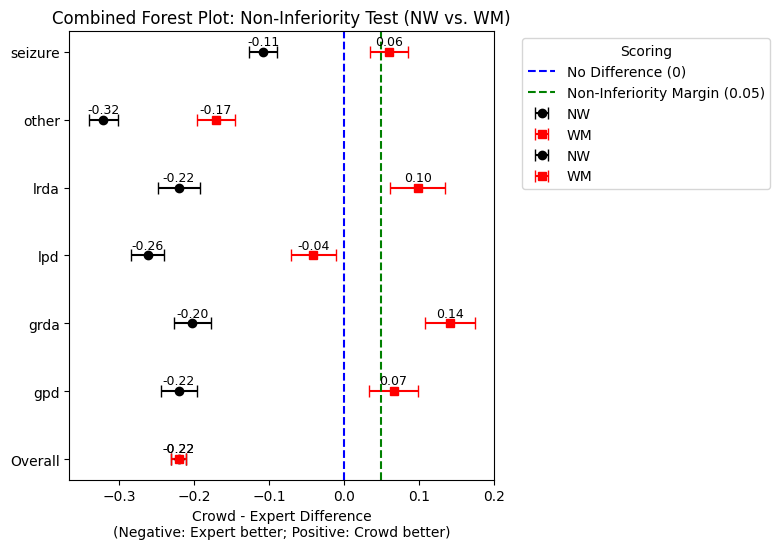

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt

##############################################
# PART 1: DATA PREPARATION & MODEL FITTING
##############################################

# Drop rows with missing values in key columns.
df = df.dropna(subset=['user_id', 'problem_id', 'title', 'goldstandardnew', 'experience_level'])

# Create variables.
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)
df['group'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Crowd')
df['user_question_count'] = df.groupby('user_id')['problem_id'].transform('nunique')

## -------------------------------
## Model 1: Overall, Non-Weighted
## -------------------------------
agg_overall_NW = df.groupby(['problem_id', 'group']).agg({
    'correct': ['mean', 'count'],
    'user_question_count': 'mean'
}).reset_index()
agg_overall_NW.columns = ['problem_id', 'group', 'accuracy', 'n', 'avg_question_count']
agg_overall_NW['group'] = agg_overall_NW['group'].astype('category')

model_overall_NW = smf.mixedlm("accuracy ~ group + avg_question_count", agg_overall_NW,
                               groups=agg_overall_NW["problem_id"])
result_overall_NW = model_overall_NW.fit()

## -------------------------------
## Model 2: By-Pattern, Non-Weighted
## -------------------------------
agg_pattern_NW = df.groupby(['problem_id', 'group', 'goldstandardnew'], observed=True).agg({
    'correct': 'mean',
    'user_question_count': 'mean'
}).reset_index()
agg_pattern_NW.rename(columns={'correct': 'accuracy',
                               'user_question_count': 'avg_question_count',
                               'goldstandardnew': 'pattern'}, inplace=True)
agg_pattern_NW['group'] = agg_pattern_NW['group'].astype('category')
agg_pattern_NW['pattern'] = agg_pattern_NW['pattern'].astype('category')

model_pattern_NW = smf.mixedlm("accuracy ~ group * pattern + avg_question_count", agg_pattern_NW,
                               groups=agg_pattern_NW["problem_id"])
result_pattern_NW = model_pattern_NW.fit()

## -------------------------------
## Model 3: Overall, Weighted
## -------------------------------
def compute_weighted_accuracy(sub_df):
    pred = sub_df.groupby('title')['combinedaccuracy'].sum().idxmax()
    gold = sub_df['goldstandardnew'].iloc[0]
    return int(pred == gold)

agg_overall_WM = df.groupby(['problem_id', 'group']).apply(
    lambda sub_df: pd.Series({
        'weighted_accuracy': compute_weighted_accuracy(sub_df),
        'avg_question_count': sub_df['user_question_count'].mean()
    })
).reset_index()

model_overall_WM = smf.mixedlm("weighted_accuracy ~ group + avg_question_count", agg_overall_WM,
                               groups=agg_overall_WM["problem_id"])
result_overall_WM = model_overall_WM.fit()

## -------------------------------
## Model 4: By-Pattern, Weighted
## -------------------------------
agg_pattern_WM = df.groupby(['problem_id', 'group', 'goldstandardnew'], observed=True).apply(
    lambda sub_df: pd.Series({
        'weighted_accuracy': compute_weighted_accuracy(sub_df),
        'avg_question_count': sub_df['user_question_count'].mean()
    })
).reset_index()
agg_pattern_WM.rename(columns={'goldstandardnew': 'pattern'}, inplace=True)
agg_pattern_WM['group'] = agg_pattern_WM['group'].astype('category')
agg_pattern_WM['pattern'] = agg_pattern_WM['pattern'].astype('category')

model_pattern_WM = smf.mixedlm("weighted_accuracy ~ group * pattern + avg_question_count", agg_pattern_WM,
                               groups=agg_pattern_WM["problem_id"])
result_pattern_WM = model_pattern_WM.fit()

##############################################
# PART 2: COMBINED BAR GRAPH: ADJUSTED PREDICTED ACCURACY
##############################################

# Compute adjusted predictions and summarize by group for overall models.
agg_overall_NW['predicted_accuracy'] = result_overall_NW.predict(agg_overall_NW)
overall_NW_summary = agg_overall_NW.groupby('group')['predicted_accuracy'].agg(['mean','std','count']).reset_index()
overall_NW_summary['se'] = overall_NW_summary['std'] / np.sqrt(overall_NW_summary['count'])
overall_NW_summary['ci'] = 1.96 * overall_NW_summary['se']
overall_NW_summary['pattern'] = 'Overall'
overall_NW_summary['scoring'] = 'NW'

agg_overall_WM['predicted_accuracy'] = result_overall_WM.predict(agg_overall_WM)
overall_WM_summary = agg_overall_WM.groupby('group')['predicted_accuracy'].agg(['mean','std','count']).reset_index()
overall_WM_summary['se'] = overall_WM_summary['std'] / np.sqrt(overall_WM_summary['count'])
overall_WM_summary['ci'] = 1.96 * overall_WM_summary['se']
overall_WM_summary['pattern'] = 'Overall'
overall_WM_summary['scoring'] = 'WM'

# For pattern models, summarize by pattern and group.
agg_pattern_NW['predicted_accuracy'] = result_pattern_NW.predict(agg_pattern_NW)
pattern_NW_summary = agg_pattern_NW.groupby(['pattern','group'])['predicted_accuracy'].agg(['mean','std','count']).reset_index()
pattern_NW_summary['se'] = pattern_NW_summary['std'] / np.sqrt(pattern_NW_summary['count'])
pattern_NW_summary['ci'] = 1.96 * pattern_NW_summary['se']
pattern_NW_summary['scoring'] = 'NW'

agg_pattern_WM['predicted_accuracy'] = result_pattern_WM.predict(agg_pattern_WM)
pattern_WM_summary = agg_pattern_WM.groupby(['pattern','group'])['predicted_accuracy'].agg(['mean','std','count']).reset_index()
pattern_WM_summary['se'] = pattern_WM_summary['std'] / np.sqrt(pattern_WM_summary['count'])
pattern_WM_summary['ci'] = 1.96 * pattern_WM_summary['se']
pattern_WM_summary['scoring'] = 'WM'

# Combine summaries.
bar_df = pd.concat([overall_NW_summary, pattern_NW_summary, overall_WM_summary, pattern_WM_summary], ignore_index=True)
# Order: Overall first, then patterns alphabetically.
cat_order = ['Overall'] + sorted([p for p in bar_df['pattern'].unique() if p != 'Overall'])
bar_df['pattern'] = pd.Categorical(bar_df['pattern'], categories=cat_order, ordered=True)
bar_df.sort_values('pattern', inplace=True)
# Standardize group label (already "Expert" or "Crowd").
bar_df['group_std'] = bar_df['group']

# Create a horizontal grouped bar plot.
categories = cat_order
scoring_levels = ['NW', 'WM']
group_levels = ['Expert', 'Crowd']
n_cat = len(categories)
base_y = np.arange(n_cat)
# Use offsets to separate NW and WM within each category.
scoring_offset = {'NW': -0.15, 'WM': 0.15}
group_offset = {'Expert': -0.07, 'Crowd': 0.07}

y_positions = []
bar_means = []
bar_cis = []
labels = []
for i, cat in enumerate(categories):
    for scoring in scoring_levels:
        for grp in group_levels:
            subset = bar_df[(bar_df['pattern'] == cat) & (bar_df['scoring'] == scoring) & (bar_df['group_std'] == grp)]
            if not subset.empty:
                mean_val = subset['mean'].values[0]
                ci_val = subset['ci'].values[0]
            else:
                mean_val = np.nan
                ci_val = np.nan
            y = base_y[i] + scoring_offset[scoring] + group_offset[grp]
            y_positions.append(y)
            bar_means.append(mean_val)
            bar_cis.append(ci_val)
            labels.append(f"{scoring}-{grp}")
y_positions = np.array(y_positions)
bar_means = np.array(bar_means)
bar_cis = np.array(bar_cis)

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(len(y_positions)):
    # Here we print the adjusted predicted accuracy (already derived via the model)
    color = 'lightgreen' if 'Expert' in labels[i] else 'skyblue'
    ax.barh(y_positions[i], bar_means[i], height=0.1, color=color, alpha=0.8)
    ax.errorbar(bar_means[i], y_positions[i], xerr=bar_cis[i], fmt='none', color='gray', capsize=3)
    ax.text(bar_means[i] + 0.005, y_positions[i], f"{bar_means[i]:.2f}", va='center', fontsize=9)
ax.set_yticks(base_y)
ax.set_yticklabels(categories)
ax.set_xlabel("Adjusted Predicted Accuracy")
ax.set_title("Combined Predicted Accuracy by Pattern & Scoring\n(NW & WM, Expert vs. Crowd)")
plt.tight_layout()
plt.show()

##############################################
# PART 3: COMBINED FOREST PLOT: NON-INFERIORITY
##############################################
# In these models the non-inferiority margin is 0.05 (null: Expert - Crowd > 0.05).
# Our extraction functions compute (Crowd - Expert) differences.
# The extraction functions below remain as before.
noninf_margin=0.05

def extract_overall_NI(result_obj, model_label='Overall'):
    params = result_obj.params
    cov = result_obj.cov_params()
    coeff_key = "group[T.Expert]"
    diff_expert_vs_crowd = params[coeff_key]
    se = np.sqrt(cov.loc[coeff_key, coeff_key])
    diff = -diff_expert_vs_crowd
    lower_expert = diff_expert_vs_crowd - 1.96 * se
    upper_expert = diff_expert_vs_crowd + 1.96 * se
    lower = -upper_expert
    upper = -lower_expert
    z = (diff - noninf_margin) / se
    p_val = norm.cdf(z)
    return {'pattern': model_label, 'scoring': None, 'difference': diff, 'se': se,
            'lower': lower, 'upper': upper, 'z': z, 'p': p_val}

def extract_pattern_NI(result_obj, patterns_list, model_label='NW'):
    params = result_obj.params
    cov = result_obj.cov_params()
    results = []
    coeff_key = "group[T.Expert]"
    diff_expert_vs_crowd = params[coeff_key]
    se_baseline = np.sqrt(cov.loc[coeff_key, coeff_key])
    lower_expert = diff_expert_vs_crowd - 1.96 * se_baseline
    upper_expert = diff_expert_vs_crowd + 1.96 * se_baseline
    diff = -diff_expert_vs_crowd
    lower = -upper_expert
    upper = -lower_expert
    z_baseline = (diff - noninf_margin) / se_baseline
    p_baseline = norm.cdf(z_baseline)
    # For the baseline pattern in the by-pattern model, use the first pattern in patterns_list.
    baseline_pattern = patterns_list[0] if patterns_list else "Baseline"
    results.append({'pattern': baseline_pattern, 'scoring': model_label, 'difference': diff,
                    'se': se_baseline, 'lower': lower, 'upper': upper,
                    'z': z_baseline, 'p': p_baseline})
    for pat in patterns_list[1:]:
        term = f"group[T.Expert]:pattern[T.{pat}]"
        if term in params.index:
            diff_expert_vs_crowd = params[coeff_key] + params[term]
            var_base = cov.loc[coeff_key, coeff_key]
            var_int = cov.loc[term, term]
            covar = cov.loc[coeff_key, term]
            se_pat = np.sqrt(var_base + var_int + 2 * covar)
            lower_expert = diff_expert_vs_crowd - 1.96 * se_pat
            upper_expert = diff_expert_vs_crowd + 1.96 * se_pat
            diff = -diff_expert_vs_crowd
            lower = -upper_expert
            upper = -lower_expert
            z_pat = (diff - noninf_margin) / se_pat
            p_pat = norm.cdf(z_pat)
            results.append({'pattern': pat, 'scoring': model_label, 'difference': diff,
                            'se': se_pat, 'lower': lower, 'upper': upper, 'z': z_pat, 'p': p_pat})
    return results

# Extract NI results.
NI_overall_NW = extract_overall_NI(result_overall_NW, model_label='Overall')
NI_overall_WM = extract_overall_NI(result_overall_WM, model_label='Overall')

all_patterns_NW = sorted(agg_pattern_NW['pattern'].unique().tolist())
patterns_NW = [p for p in all_patterns_NW if p != "Overall"]
NI_pattern_NW = extract_pattern_NI(result_pattern_NW, patterns_NW, model_label='NW')

all_patterns_WM = sorted(agg_pattern_WM['pattern'].unique().tolist())
patterns_WM = [p for p in all_patterns_WM if p != "Overall"]
NI_pattern_WM = extract_pattern_NI(result_pattern_WM, patterns_WM, model_label='WM')

# Combine overall and pattern NI results.
NI_results = pd.DataFrame([NI_overall_NW] + [NI_overall_WM] + NI_pattern_NW + NI_pattern_WM)
# Define plotting order: Overall first, then other patterns alphabetically.
cat_order = ['Overall'] + sorted([p for p in NI_results['pattern'].unique() if p != 'Overall'])
NI_results['pattern'] = pd.Categorical(NI_results['pattern'], categories=cat_order, ordered=True)
NI_results.sort_values(['pattern', 'scoring'], inplace=True)

# Remap y positions: assign each category a unique y coordinate.
y_mapping = {cat: i for i, cat in enumerate(cat_order)}

# Prepare data for forest plot.
forest_list = []
for cat in cat_order:
    for scoring in ['NW', 'WM']:
        if cat == 'Overall':
            row = NI_results[NI_results['pattern'] == cat]
            if not row.empty:
                row = row.copy()
                row['scoring'] = scoring
        else:
            row = NI_results[(NI_results['pattern'] == cat) & (NI_results['scoring'] == scoring)]
        if not row.empty:
            forest_list.append({
                'pattern': cat,
                'scoring': scoring,
                'difference': row['difference'].values[0],
                'lower': row['lower'].values[0],
                'upper': row['upper'].values[0],
                'y': y_mapping[cat]
            })
forest_plot_df = pd.DataFrame(forest_list)

# Create the forest plot.
fig, ax = plt.subplots(figsize=(8, len(cat_order)*0.8))
for idx, r in forest_plot_df.iterrows():
    marker = 'o' if r['scoring'] == 'NW' else 's'
    color = 'black' if r['scoring'] == 'NW' else 'red'
    ax.errorbar(r['difference'], r['y'],
                xerr=[[r['difference'] - r['lower']], [r['upper'] - r['difference']]],
                fmt=marker, capsize=4, color=color,
                label=r['scoring'] if r['y'] in [min(forest_plot_df['y']), max(forest_plot_df['y'])] else "")
    # Place the point estimate label above the marker (0.1 units above)
    ax.text(r['difference'], r['y'] + 0.1, f"{r['difference']:.2f}", ha='center', fontsize=9)
ax.axvline(x=0, color='blue', linestyle='--', label='No Difference (0)')
ax.axvline(x=noninf_margin, color='green', linestyle='--', label=f'Non-Inferiority Margin ({noninf_margin})')
yticks = [y_mapping[cat] for cat in cat_order]
ax.set_yticks(yticks)
ax.set_yticklabels(cat_order)
ax.set_xlabel("Crowd - Expert Difference\n(Negative: Expert better; Positive: Crowd better)")
ax.set_title("Combined Forest Plot: Non-Inferiority Test (NW vs. WM)")
ax.legend(title="Scoring", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Unique patterns before renaming:
['Overall', 'gpd', 'grda', 'lpd', 'lrda', 'other', 'seizure']
Categories (7, object): ['Overall' < 'gpd' < 'grda' < 'lpd' < 'lrda' < 'other' < 'seizure']


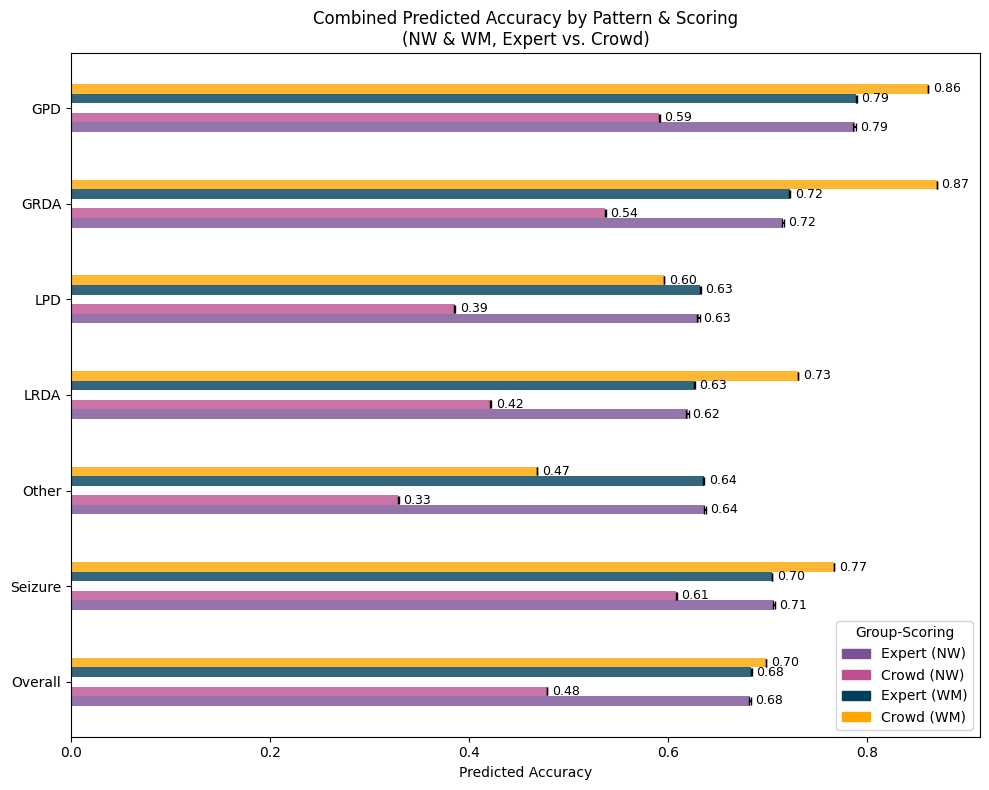

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Provided muted colors.
colors = {
    'Expert (NW)': '#7a5195',   # Light blue
    'Crowd (NW)': '#bc5090',    # Dark orange (muted)
    'Expert (WM)': '#003f5c',   # Dark blue
    'Crowd (WM)': '#ffa600'     # Light orange (muted)
}

# Print unique pattern names to check.
print("Unique patterns before renaming:")
print(bar_df['pattern'].unique())

# Renaming dictionary (adjust keys as needed)
rename_dict = {
    'gpd': 'GPD',
    'seizure': 'Seizure',
    'other': 'Other',
    'lrda': 'LRDA',
    'lpd': 'LPD',
    'grda': 'GRDA',
    'Overall': 'Overall'
}
bar_df['pattern'] = bar_df['pattern'].apply(lambda x: rename_dict.get(x, x))

# Define the order of categories for plotting.
cat_order = ['Overall', 'Seizure', 'Other', 'LRDA', 'LPD', 'GRDA', 'GPD']
bar_df['pattern'] = pd.Categorical(bar_df['pattern'], categories=cat_order, ordered=True)
bar_df.sort_values('pattern', inplace=True)

# Ensure the standardized group column is present.
bar_df['group_std'] = bar_df['group']

# For the horizontal bar plot, we want two clusters per pattern:
# one for NW and one for WM. Within each cluster, Expert and Crowd bars should be directly adjacent.
n_cat = len(cat_order)
base_y = np.arange(n_cat)
cluster_gap = 0.3   # vertical gap between NW and WM clusters

# Within each cluster, we want Expert and Crowd to be adjacent. With bar height = 0.1,
# placing one bar centered at (cluster_center - 0.05) and the other at (cluster_center + 0.05)
# means their edges exactly touch.
nw_expert_offset = -0.05
nw_crowd_offset  =  0.05
wm_expert_offset = -0.05
wm_crowd_offset  =  0.05

y_positions = []
bar_means = []
bar_cis = []
labels = []  # e.g. "NW Expert", "NW Crowd", "WM Expert", "WM Crowd"

for i, cat in enumerate(cat_order):
    # NW cluster: center = base_y[i]
    for grp, off in zip(['Expert', 'Crowd'], [nw_expert_offset, nw_crowd_offset]):
        subset = bar_df[(bar_df['pattern'] == cat) &
                        (bar_df['scoring'] == 'NW') &
                        (bar_df['group_std'] == grp)]
        if not subset.empty:
            mean_val = subset['mean'].values[0]
            ci_val = subset['ci'].values[0]
        else:
            mean_val = np.nan
            ci_val = np.nan
        y = base_y[i] + off
        y_positions.append(y)
        bar_means.append(mean_val)
        bar_cis.append(ci_val)
        labels.append(f"NW {grp}")
    # WM cluster: center = base_y[i] + cluster_gap
    for grp, off in zip(['Expert', 'Crowd'], [wm_expert_offset, wm_crowd_offset]):
        subset = bar_df[(bar_df['pattern'] == cat) &
                        (bar_df['scoring'] == 'WM') &
                        (bar_df['group_std'] == grp)]
        if not subset.empty:
            mean_val = subset['mean'].values[0]
            ci_val = subset['ci'].values[0]
        else:
            mean_val = np.nan
            ci_val = np.nan
        y = base_y[i] + cluster_gap + off
        y_positions.append(y)
        bar_means.append(mean_val)
        bar_cis.append(ci_val)
        labels.append(f"WM {grp}")

y_positions = np.array(y_positions)
bar_means = np.array(bar_means)
bar_cis = np.array(bar_cis)

# Create the horizontal bar plot.
fig, ax = plt.subplots(figsize=(10, 8))
for i in range(len(y_positions)):
    # Build the key for colors: e.g., "Expert (NW)" from label "NW Expert"
    parts = labels[i].split()
    key = f"{parts[1]} ({parts[0]})"  # e.g., "Expert (NW)" or "Crowd (WM)"
    color = colors.get(key, 'gray')
    ax.barh(y_positions[i], bar_means[i], height=0.1, color=color, alpha=0.8)
    ax.errorbar(bar_means[i], y_positions[i], xerr=bar_cis[i], fmt='none', color='black', capsize=3)
    ax.text(bar_means[i] + 0.005, y_positions[i], f"{bar_means[i]:.2f}", va='center', fontsize=9)

# Set y-axis ticks at the center of each category.
# We want to label each pattern once at the midpoint between NW and WM clusters.
ax.set_yticks(base_y + cluster_gap/2)
ax.set_yticklabels(cat_order)
ax.set_xlabel("Predicted Accuracy")
ax.set_title("Combined Predicted Accuracy by Pattern & Scoring\n(NW & WM, Expert vs. Crowd)")

# Create a custom legend.
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=colors['Expert (NW)'], label='Expert (NW)'),
    mpatches.Patch(color=colors['Crowd (NW)'], label='Crowd (NW)'),
    mpatches.Patch(color=colors['Expert (WM)'], label='Expert (WM)'),
    mpatches.Patch(color=colors['Crowd (WM)'], label='Crowd (WM)')
]
ax.legend(handles=legend_patches, title="Group-Scoring", loc='lower right')

plt.tight_layout()
plt.show()


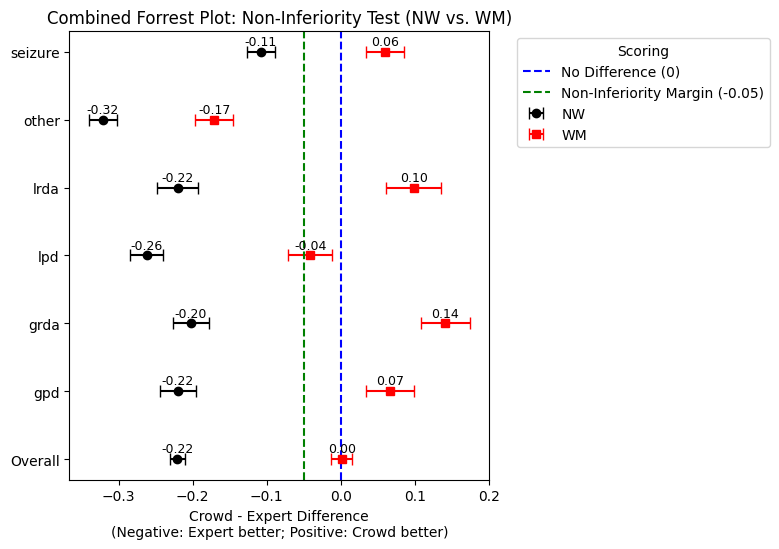

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

noninf_margin = -0.05

def extract_overall_NI(result_obj, patterns_list='Overall', model_label='NW'):
    params = result_obj.params
    cov = result_obj.cov_params()
    # With Crowd as reference, the key is "group[T.Expert]" which equals (Expert – Crowd)
    coeff_key = "group[T.Expert]"
    diff_expert_vs_crowd = params[coeff_key]
    se = np.sqrt(cov.loc[coeff_key, coeff_key])
    # Convert to (Crowd - Expert)
    diff = -diff_expert_vs_crowd
    # Compute 95% CI for (Expert - Crowd)
    lower_expert = diff_expert_vs_crowd - 1.96 * se
    upper_expert = diff_expert_vs_crowd + 1.96 * se
    # Reverse CI for (Crowd - Expert)
    lower = -upper_expert
    upper = -lower_expert
    z = (diff - noninf_margin) / se
    p_val = norm.cdf(z)
    return {'pattern': patterns_list, 'scoring': model_label, 'difference': diff, 'se': se,
            'lower': lower, 'upper': upper, 'z': z, 'p': p_val}

def extract_pattern_NI(result_obj, patterns_list, model_label='NW'):
    params = result_obj.params
    cov = result_obj.cov_params()
    results = []
    # Baseline: from the pattern model; we use the first pattern in patterns_list as the baseline label.
    coeff_key = "group[T.Expert]"
    diff_expert_vs_crowd = params[coeff_key]
    se_baseline = np.sqrt(cov.loc[coeff_key, coeff_key])
    lower_expert = diff_expert_vs_crowd - 1.96 * se_baseline
    upper_expert = diff_expert_vs_crowd + 1.96 * se_baseline
    diff = -diff_expert_vs_crowd  # (Crowd - Expert)
    lower = -upper_expert
    upper = -lower_expert
    z_baseline = (diff - noninf_margin) / se_baseline
    p_baseline = norm.cdf(z_baseline)
    baseline_pattern = patterns_list[0] if patterns_list else "Baseline"
    results.append({'pattern': baseline_pattern, 'scoring': model_label, 'difference': diff,
                    'se': se_baseline, 'lower': lower, 'upper': upper,
                    'z': z_baseline, 'p': p_baseline})
    for pat in patterns_list[1:]:
        term = f"group[T.Expert]:pattern[T.{pat}]"
        if term in params.index:
            diff_expert_vs_crowd = params[coeff_key] + params[term]
            var_base = cov.loc[coeff_key, coeff_key]
            var_int = cov.loc[term, term]
            covar = cov.loc[coeff_key, term]
            se_pat = np.sqrt(var_base + var_int + 2 * covar)
            lower_expert = diff_expert_vs_crowd - 1.96 * se_pat
            upper_expert = diff_expert_vs_crowd + 1.96 * se_pat
            diff = -diff_expert_vs_crowd  # (Crowd - Expert)
            lower = -upper_expert
            upper = -lower_expert
            z_pat = (diff - noninf_margin) / se_pat
            p_pat = norm.cdf(z_pat)
            results.append({'pattern': pat, 'scoring': model_label, 'difference': diff,
                            'se': se_pat, 'lower': lower, 'upper': upper, 'z': z_pat, 'p': p_pat})
    return results

# IMPORTANT: For overall results, use model_label="Overall" (not "NW" or "WM")
NI_overall_NW = extract_overall_NI(result_overall_NW, patterns_list='Overall', model_label='NW')
NI_overall_WM = extract_overall_NI(result_overall_WM, patterns_list='Overall', model_label='WM')

# For pattern results, we exclude "Overall" (if present) and use "NW" or "WM".
all_patterns_NW = sorted(agg_pattern_NW['pattern'].unique().tolist())
patterns_NW = [p for p in all_patterns_NW if p != "Overall"]
NI_pattern_NW = extract_pattern_NI(result_pattern_NW, patterns_NW, model_label='NW')

all_patterns_WM = sorted(agg_pattern_WM['pattern'].unique().tolist())
patterns_WM = [p for p in all_patterns_WM if p != "Overall"]
NI_pattern_WM = extract_pattern_NI(result_pattern_WM, patterns_WM, model_label='WM')

# Combine all NI results.
NI_results = pd.DataFrame([NI_overall_NW] + [NI_overall_WM] + NI_pattern_NW + NI_pattern_WM)

# Define plotting order: Overall first, then remaining patterns alphabetically.
cat_order = ['Overall'] + sorted([p for p in NI_results['pattern'].unique() if p != 'Overall'])
NI_results['pattern'] = pd.Categorical(NI_results['pattern'], categories=cat_order, ordered=True)
NI_results.sort_values(['pattern', 'scoring'], inplace=True)

y_mapping = {}
for i, cat in enumerate(cat_order):
    y_mapping[cat] = i  # now each category gets a unique y (0, 1, 2, ...)

# Prepare data for the forest plot.
forest_list = []
for cat in cat_order:
    for scoring in ['NW', 'WM']:
        row = NI_results[(NI_results['pattern'] == cat) & (NI_results['scoring'] == scoring)]
        if not row.empty:
            offset = 0.15 if scoring == 'WM' else -0.15
            forest_list.append({
                'pattern': cat,
                'scoring': scoring,
                'difference': row['difference'].values[0],
                'lower': row['lower'].values[0],
                'upper': row['upper'].values[0],
                'y': y_mapping[cat]
            })
forest_plot_df = pd.DataFrame(forest_list)

# Create the forest plot.
fig, ax = plt.subplots(figsize=(8, len(cat_order)*0.8))
for idx, r in forest_plot_df.iterrows():
    marker = 'o' if r['scoring'] == 'NW' else 's'
    # Use black for NW and red for WM.
    color = 'black' if r['scoring'] == 'NW' else 'red'
    ax.errorbar(r['difference'], r['y'],
                xerr=[[r['difference'] - r['lower']], [r['upper'] - r['difference']]],
                fmt=marker, capsize=4, color=color,
                label=r['scoring'] if r['y'] == forest_plot_df['y'].min() or r['y'] == forest_plot_df['y'].max() else "")
    # Label point estimate slightly above the marker.
    ax.text(r['difference'], r['y'] + 0.1, f"{r['difference']:.2f}", ha='center', fontsize=9)
ax.axvline(x=0, color='blue', linestyle='--', label='No Difference (0)')
ax.axvline(x=noninf_margin, color='green', linestyle='--', label=f'Non-Inferiority Margin ({noninf_margin})')
yticks = [y_mapping[cat] for cat in cat_order]
ax.set_yticks(yticks)
ax.set_yticklabels(cat_order)
ax.set_xlabel("Crowd - Expert Difference\n(Negative: Expert better; Positive: Crowd better)")
ax.set_title("Combined Forrest Plot: Non-Inferiority Test (NW vs. WM)")
handles, labels = ax.get_legend_handles_labels()
# Create a dictionary to drop duplicate entries:
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Scoring", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


MODEL SUMMARY

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

##############################################
# PART 1: Accuracy Summary Statistics
##############################################

# --- Overall, Non-Weighted (Model 1) ---
overall_NW_stats = agg_overall_NW.groupby('group').agg(
    mean_accuracy=('accuracy','mean'),
    std_accuracy=('accuracy','std'),
    count=('accuracy','count')
).reset_index()
overall_NW_stats['se'] = overall_NW_stats['std_accuracy'] / np.sqrt(overall_NW_stats['count'])
overall_NW_stats['ci'] = 1.96 * overall_NW_stats['se']

print("=== Overall Non-Weighted Accuracy Summary ===")
print(overall_NW_stats)

# --- Overall, Weighted (Model 3) ---
# (Assumes that you computed a predicted_accuracy column in agg_overall_WM)
overall_WM_stats = agg_overall_WM.groupby('group').agg(
    mean_accuracy=('weighted_accuracy','mean'),
    std_accuracy=('weighted_accuracy','std'),
    count=('weighted_accuracy','count')
).reset_index()
overall_WM_stats['se'] = overall_WM_stats['std_accuracy'] / np.sqrt(overall_WM_stats['count'])
overall_WM_stats['ci'] = 1.96 * overall_WM_stats['se']

print("\n=== Overall Weighted Accuracy Summary ===")
print(overall_WM_stats)

# --- Pattern, Non-Weighted (Model 2) ---
pattern_NW_stats = agg_pattern_NW.groupby(['pattern','group']).agg(
    mean_accuracy=('accuracy','mean'),
    std_accuracy=('accuracy','std'),
    count=('accuracy','count')
).reset_index()
pattern_NW_stats['se'] = pattern_NW_stats['std_accuracy'] / np.sqrt(pattern_NW_stats['count'])
pattern_NW_stats['ci'] = 1.96 * pattern_NW_stats['se']

print("\n=== Pattern Non-Weighted Accuracy Summary ===")
print(pattern_NW_stats)

# --- Pattern, Weighted (Model 4) ---
pattern_WM_stats = agg_pattern_WM.groupby(['pattern','group']).agg(
    mean_accuracy=('weighted_accuracy','mean'),
    std_accuracy=('weighted_accuracy','std'),
    count=('weighted_accuracy','count')
).reset_index()
pattern_WM_stats['se'] = pattern_WM_stats['std_accuracy'] / np.sqrt(pattern_WM_stats['count'])
pattern_WM_stats['ci'] = 1.96 * pattern_WM_stats['se']

print("\n=== Pattern Weighted Accuracy Summary ===")
print(pattern_WM_stats)

##############################################
# PART 2: Non-Inferiority Test Results
##############################################

# For overall models, we use the coefficient "group[T.Expert]" which (with Crowd as reference)
# equals Expert – Crowd. The null hypothesis is: Expert – Crowd > 0.05.
# We'll print the point estimate, 95% CI, and one-sided NI p-value.

print("\n=== Overall Non-Weighted NI Test (Expert - Crowd) ===")
diff_NW_overall = result_overall_NW.params["group[T.Expert]"]
se_NW_overall = np.sqrt(result_overall_NW.cov_params().loc["group[T.Expert]", "group[T.Expert]"])
ci_NW_overall = (diff_NW_overall - 1.96 * se_NW_overall, diff_NW_overall + 1.96 * se_NW_overall)
z_NW_overall = (diff_NW_overall - 0.05) / se_NW_overall
p_NW_overall = norm.cdf(z_NW_overall)
print("Expert - Crowd difference (NW overall): {:.3f}".format(diff_NW_overall))
print("95% CI: [{:.3f}, {:.3f}]".format(ci_NW_overall[0], ci_NW_overall[1]))
print("Non-inferiority p-value (NW overall): {:.4f}".format(p_NW_overall))

print("\n=== Overall Weighted NI Test (Expert - Crowd) ===")
diff_WM_overall = result_overall_WM.params["group[T.Expert]"]
se_WM_overall = np.sqrt(result_overall_WM.cov_params().loc["group[T.Expert]", "group[T.Expert]"])
ci_WM_overall = (diff_WM_overall - 1.96 * se_WM_overall, diff_WM_overall + 1.96 * se_WM_overall)
z_WM_overall = (diff_WM_overall - 0.05) / se_WM_overall
p_WM_overall = norm.cdf(z_WM_overall)
print("Expert - Crowd difference (WM overall): {:.3f}".format(diff_WM_overall))
print("95% CI: [{:.3f}, {:.3f}]".format(ci_WM_overall[0], ci_WM_overall[1]))
print("Non-inferiority p-value (WM overall): {:.4f}".format(p_WM_overall))

# For pattern models, we need to extract the NI estimates.
# We'll use extraction functions that compute (Crowd - Expert) differences.
# (Note: our extraction functions below produce (Crowd - Expert) values.)
def extract_overall_NI_model(result_obj, model_label='Overall'):
    params = result_obj.params
    cov = result_obj.cov_params()
    coeff_key = "group[T.Expert]"
    diff_expert_vs_crowd = params[coeff_key]
    se = np.sqrt(cov.loc[coeff_key, coeff_key])
    # For pattern NI, we want expert - crowd difference, so leave as is.
    return {'pattern': model_label, 'scoring': None, 'diff_expert_minus_crowd': diff_expert_vs_crowd,
            'se': se, 'lower': diff_expert_vs_crowd - 1.96 * se,
            'upper': diff_expert_vs_crowd + 1.96 * se}

# For pattern models, we need to extract the NI estimates (expert - crowd) for each pattern.
def extract_pattern_NI_model(result_obj, patterns_list, model_label='NW'):
    params = result_obj.params
    cov = result_obj.cov_params()
    results = []
    coeff_key = "group[T.Expert]"
    base_diff = params[coeff_key]
    base_se = np.sqrt(cov.loc[coeff_key, coeff_key])
    results.append({'pattern': patterns_list[0] if patterns_list else "Baseline", 'scoring': model_label,
                    'diff_expert_minus_crowd': base_diff,
                    'se': base_se,
                    'lower': base_diff - 1.96 * base_se,
                    'upper': base_diff + 1.96 * base_se})
    for pat in patterns_list[1:]:
        term = f"group[T.Expert]:pattern[T.{pat}]"
        if term in params.index:
            diff = params[coeff_key] + params[term]
            se_pat = np.sqrt(cov.loc[coeff_key, coeff_key] + cov.loc[term, term] + 2 * cov.loc[coeff_key, term])
            results.append({'pattern': pat, 'scoring': model_label,
                            'diff_expert_minus_crowd': diff,
                            'se': se_pat,
                            'lower': diff - 1.96 * se_pat,
                            'upper': diff + 1.96 * se_pat})
    return results

# Extract pattern NI results (for NW and WM), without overall.
all_patterns_NW = sorted(agg_pattern_NW['pattern'].unique().tolist())
patterns_NW = [p for p in all_patterns_NW if p != "Overall"]
NI_pattern_NW_model = extract_pattern_NI_model(result_pattern_NW, patterns_NW, model_label='NW')

all_patterns_WM = sorted(agg_pattern_WM['pattern'].unique().tolist())
patterns_WM = [p for p in all_patterns_WM if p != "Overall"]
NI_pattern_WM_model = extract_pattern_NI_model(result_pattern_WM, patterns_WM, model_label='WM')

# Convert pattern NI results to DataFrames and apply Bonferroni correction.
NI_pattern_NW_df = pd.DataFrame(NI_pattern_NW_model)
reject, pvals_corr_NW, _, _ = multipletests(NI_pattern_NW_df['p'] if 'p' in NI_pattern_NW_df.columns else NI_pattern_NW_df['diff_expert_minus_crowd'],
                                            alpha=0.05, method='bonferroni')
# Here, our extraction function did not compute p-values; if desired, compute them:
NI_pattern_NW_df['z'] = (NI_pattern_NW_df['diff_expert_minus_crowd'] - 0.05) / NI_pattern_NW_df['se']
NI_pattern_NW_df['p'] = norm.cdf(NI_pattern_NW_df['z'])
reject, pvals_corr_NW, _, _ = multipletests(NI_pattern_NW_df['p'], alpha=0.05, method='bonferroni')
NI_pattern_NW_df['p_adj'] = pvals_corr_NW

NI_pattern_WM_df = pd.DataFrame(NI_pattern_WM_model)
NI_pattern_WM_df['z'] = (NI_pattern_WM_df['diff_expert_minus_crowd'] - 0.05) / NI_pattern_WM_df['se']
NI_pattern_WM_df['p'] = norm.cdf(NI_pattern_WM_df['z'])
reject, pvals_corr_WM, _, _ = multipletests(NI_pattern_WM_df['p'], alpha=0.05, method='bonferroni')
NI_pattern_WM_df['p_adj'] = pvals_corr_WM

print("\n=== Overall NI Test (Non-Weighted) ===")
print("Expert - Crowd difference (NW overall): {:.3f}".format(diff_NW_overall))
print("95% CI: [{:.3f}, {:.3f}]".format(ci_NW_overall[0], ci_NW_overall[1]))
print("Non-inferiority p-value (NW overall): {:.4f}".format(p_NW_overall))

print("\n=== Overall NI Test (Weighted) ===")
print("Expert - Crowd difference (WM overall): {:.3f}".format(diff_WM_overall))
print("95% CI: [{:.3f}, {:.3f}]".format(ci_WM_overall[0], ci_WM_overall[1]))
print("Non-inferiority p-value (WM overall): {:.4f}".format(p_WM_overall))

print("\n=== Pattern NI Tests (Non-Weighted, Bonferroni corrected) ===")
print(NI_pattern_NW_df[['pattern', 'diff_expert_minus_crowd', 'lower', 'upper', 'p', 'p_adj']])
print("\n=== Pattern NI Tests (Weighted, Bonferroni corrected) ===")
print(NI_pattern_WM_df[['pattern', 'diff_expert_minus_crowd', 'lower', 'upper', 'p', 'p_adj']])


=== Overall Non-Weighted Accuracy Summary ===
    group  mean_accuracy  std_accuracy  count        se        ci
0   Crowd       0.478009      0.255365   8894  0.002708  0.005307
1  Expert       0.682797      0.440231   5880  0.005741  0.011252

=== Overall Weighted Accuracy Summary ===
    group  mean_accuracy  std_accuracy  count        se        ci
0   Crowd       0.698224      0.459055   8894  0.004868  0.009541
1  Expert       0.686735      0.463861   5880  0.006049  0.011856

=== Pattern Non-Weighted Accuracy Summary ===
    pattern   group  mean_accuracy  std_accuracy  count        se        ci
0       gpd   Crowd       0.591061      0.204581   1420  0.005429  0.010641
1       gpd  Expert       0.788084      0.388555    835  0.013446  0.026355
2      grda   Crowd       0.536547      0.166443   1242  0.004723  0.009257
3      grda  Expert       0.716524      0.422377    820  0.014750  0.028910
4       lpd   Crowd       0.385712      0.196511   1511  0.005055  0.009909
5       lpd 

<ipython-input-18-0b04dacfa779>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_NW_stats = agg_overall_NW.groupby('group').agg(
<ipython-input-18-0b04dacfa779>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pattern_NW_stats = agg_pattern_NW.groupby(['pattern','group']).agg(
<ipython-input-18-0b04dacfa779>:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pattern_WM_stats = agg_pattern_WM.groupby(['pattern','

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

##############################################
# PART 1: Adjusted (ANCOVA) Accuracy Summary Statistics
##############################################

# --- Overall, Non-Weighted (Model 1) ---
# Compute the adjusted predicted accuracy from the mixed-effects model.
agg_overall_NW['predicted_accuracy'] = result_overall_NW.predict(agg_overall_NW)
overall_NW_stats = agg_overall_NW.groupby('group').agg(
    mean_accuracy=('predicted_accuracy','mean'),
    std_accuracy=('predicted_accuracy','std'),
    count=('predicted_accuracy','count')
).reset_index()
overall_NW_stats['se'] = overall_NW_stats['std_accuracy'] / np.sqrt(overall_NW_stats['count'])
overall_NW_stats['ci'] = 1.96 * overall_NW_stats['se']

print("=== Adjusted Overall Non-Weighted Accuracy Summary (ANCOVA) ===")
print(overall_NW_stats)

# --- Overall, Weighted (Model 3) ---
agg_overall_WM['predicted_accuracy'] = result_overall_WM.predict(agg_overall_WM)
overall_WM_stats = agg_overall_WM.groupby('group').agg(
    mean_accuracy=('predicted_accuracy','mean'),
    std_accuracy=('predicted_accuracy','std'),
    count=('predicted_accuracy','count')
).reset_index()
overall_WM_stats['se'] = overall_WM_stats['std_accuracy'] / np.sqrt(overall_WM_stats['count'])
overall_WM_stats['ci'] = 1.96 * overall_WM_stats['se']

print("\n=== Adjusted Overall Weighted Accuracy Summary (ANCOVA) ===")
print(overall_WM_stats)

# --- Pattern, Non-Weighted (Model 2) ---
agg_pattern_NW['predicted_accuracy'] = result_pattern_NW.predict(agg_pattern_NW)
pattern_NW_stats = agg_pattern_NW.groupby(['pattern', 'group']).agg(
    mean_accuracy=('predicted_accuracy','mean'),
    std_accuracy=('predicted_accuracy','std'),
    count=('predicted_accuracy','count')
).reset_index()
pattern_NW_stats['se'] = pattern_NW_stats['std_accuracy'] / np.sqrt(pattern_NW_stats['count'])
pattern_NW_stats['ci'] = 1.96 * pattern_NW_stats['se']
pattern_NW_stats['scoring'] = 'NW'

print("\n=== Adjusted Pattern Non-Weighted Accuracy Summary (ANCOVA) ===")
print(pattern_NW_stats)

# --- Pattern, Weighted (Model 4) ---
agg_pattern_WM['predicted_accuracy'] = result_pattern_WM.predict(agg_pattern_WM)
pattern_WM_stats = agg_pattern_WM.groupby(['pattern', 'group']).agg(
    mean_accuracy=('predicted_accuracy','mean'),
    std_accuracy=('predicted_accuracy','std'),
    count=('predicted_accuracy','count')
).reset_index()
pattern_WM_stats['se'] = pattern_WM_stats['std_accuracy'] / np.sqrt(pattern_WM_stats['count'])
pattern_WM_stats['ci'] = 1.96 * pattern_WM_stats['se']
pattern_WM_stats['scoring'] = 'WM'

print("\n=== Adjusted Pattern Weighted Accuracy Summary (ANCOVA) ===")
print(pattern_WM_stats)


<ipython-input-10-81b92d1353ba>:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_NW_stats = agg_overall_NW.groupby('group').agg(
<ipython-input-10-81b92d1353ba>:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pattern_NW_stats = agg_pattern_NW.groupby(['pattern', 'group']).agg(


=== Adjusted Overall Non-Weighted Accuracy Summary (ANCOVA) ===
    group  mean_accuracy  std_accuracy  count        se        ci
0   Crowd       0.478009      0.009549   8894  0.000101  0.000198
1  Expert       0.682124      0.020201   5880  0.000263  0.000516

=== Adjusted Overall Weighted Accuracy Summary (ANCOVA) ===
    group  mean_accuracy  std_accuracy  count        se        ci
0   Crowd       0.698224      0.007721   8894  0.000082  0.000160
1  Expert       0.683536      0.016332   5880  0.000213  0.000417

=== Adjusted Pattern Non-Weighted Accuracy Summary (ANCOVA) ===
    pattern   group  mean_accuracy  std_accuracy  count        se        ci  \
0       gpd   Crowd       0.591061      0.008728   1420  0.000232  0.000454   
1       gpd  Expert       0.787486      0.021139    835  0.000732  0.001434   
2      grda   Crowd       0.536547      0.007576   1242  0.000215  0.000421   
3      grda  Expert       0.715282      0.020949    820  0.000732  0.001434   
4       lpd   Crowd

<ipython-input-10-81b92d1353ba>:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pattern_WM_stats = agg_pattern_WM.groupby(['pattern', 'group']).agg(


In [ ]:
# Increase precision for printing Pandas output.
pd.set_option('display.precision', 6)

# Print output for Model 1: Overall, Non-Weighted
print("=== Model 1: Overall, Non-Weighted ===")
print(result_overall_NW.summary())
print("Parameters (Model 1):")
print(result_overall_NW.params.apply(lambda x: f"{x:.6f}"))
print("\n")

# Print output for Model 2: By-Pattern, Non-Weighted
print("=== Model 2: By-Pattern, Non-Weighted ===")
print(result_pattern_NW.summary())
print("Parameters (Model 2):")
print(result_pattern_NW.params.apply(lambda x: f"{x:.6f}"))
print("\n")

# Print output for Model 3: Overall, Weighted
print("=== Model 3: Overall, Weighted ===")
print(result_overall_WM.summary())
print("Parameters (Model 3):")
print(result_overall_WM.params.apply(lambda x: f"{x:.6f}"))
print("\n")

# Print output for Model 4: By-Pattern, Weighted
print("=== Model 4: By-Pattern, Weighted ===")
print(result_pattern_WM.summary())
print("Parameters (Model 4):")
print(result_pattern_WM.params.apply(lambda x: f"{x:.6f}"))


=== Model 1: Overall, Non-Weighted ===
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  accuracy  
No. Observations:   14774    Method:              REML      
No. Groups:         8894     Scale:               0.0705    
Min. group size:    1        Log-Likelihood:      -4519.7869
Max. group size:    2        Converged:           Yes       
Mean group size:    1.7                                     
------------------------------------------------------------
                   Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.422    0.010 41.575 0.000  0.402  0.442
group[T.Expert]    0.221    0.005 41.157 0.000  0.210  0.231
avg_question_count 0.000    0.000  5.899 0.000  0.000  0.000
Group Var          0.044    0.007                           

Parameters (Model 1):
Intercept             0.422012
group[T.Expert]       0.220612
avg_question_count    0.000014
Gro

Figure 3 (long time to process, especially if bootstrap to 1000)

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import random
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

# Assuming df is your DataFrame
# Step 1: Stratify by expert level
experts = df[df['experience_level'] == 'Expert']
non_experts = df[df['experience_level'] != 'Expert']

def compute_majority_accuracy(data):
    # Step 2: Compute majority vote and correctness
    majority_answer = data.groupby('problem_id').apply(
        lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
    )
    correct_answers = data.groupby('problem_id')['goldstandardnew'].first()
    majority_correct = (majority_answer == correct_answers).fillna(False)

    # Step 3: Calculate accuracy and 95% CI
    accuracy = majority_correct.mean()
    n = data['problem_id'].nunique()  # Total problems evaluated
    se = np.sqrt(accuracy * (1 - accuracy) / n)
    ci = stats.norm.interval(0.95, loc=accuracy, scale=se)

    return accuracy, ci

# Compute for experts
expert_accuracy, expert_ci = compute_majority_accuracy(experts)

# Step 2: Sensitivity analysis for non-experts
def bootstrap_majority_accuracy(data, sample_size, n_bootstrap=10):
    problem_ids = data['problem_id'].unique()
    bootstrapped_accuracies = []

    def bootstrap_iteration(_):
        sampled_data_list = []

        for pid in problem_ids:
            filtered_data = data[data['problem_id'] == pid]
            if filtered_data['user_id'].nunique() > sample_size:
                sampled_users = random.sample(list(filtered_data['user_id'].unique()), sample_size)
                sampled_data_list.append(filtered_data[filtered_data['user_id'].isin(sampled_users)])

        if sampled_data_list:
            sampled_data = pd.concat(sampled_data_list)
            accuracy, _ = compute_majority_accuracy(sampled_data)
            return accuracy
        return None

    bootstrapped_accuracies = Parallel(n_jobs=-1)(delayed(bootstrap_iteration)(_) for _ in tqdm(range(n_bootstrap), desc="Bootstrapping"))

    # Filter out None values if any
    bootstrapped_accuracies = [acc for acc in bootstrapped_accuracies if acc is not None]

    # Calculate the average accuracy over the bootstrap samples
    avg_bootstrap_accuracy = np.mean(bootstrapped_accuracies)

    # Calculate the 95% confidence interval using percentiles
    lower_bound = np.percentile(bootstrapped_accuracies, 2.5)
    upper_bound = np.percentile(bootstrapped_accuracies, 97.5)
    ci_bootstrap = (lower_bound, upper_bound)

    return avg_bootstrap_accuracy, ci_bootstrap

# Sample sizes to evaluate
sample_sizes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# Store results for plotting
non_expert_accuracies = []
non_expert_cis = []

for sample_size in tqdm(sample_sizes, desc="Processing Sample Sizes"):
    non_expert_accuracy, non_expert_ci = bootstrap_majority_accuracy(non_experts, sample_size, n_bootstrap=10)
    non_expert_accuracies.append(non_expert_accuracy)
    non_expert_cis.append(non_expert_ci)

# Visualization
plt.figure(figsize=(12, 8))

# Plot expert accuracy (horizontal line)
plt.axhline(y=expert_accuracy, color='blue', linestyle='-', label='Expert Accuracy')
plt.text(x=sample_sizes[-1] + 2, y=expert_accuracy,
         s=f'{expert_accuracy:.2f}\n[{expert_ci[0]:.2f}, {expert_ci[1]:.2f}]',
         color='blue', va='center')

# Plot non-expert accuracies with error bars
lower_errors = [acc - ci[0] for acc, ci in zip(non_expert_accuracies, non_expert_cis)]
upper_errors = [ci[1] - acc for acc, ci in zip(non_expert_accuracies, non_expert_cis)]
yerr = [lower_errors, upper_errors]

plt.errorbar(sample_sizes, non_expert_accuracies,
             yerr=yerr, fmt='o-', color='green', capsize=5, label='Non-Expert Bootstrapped Accuracy')

# Annotate non-expert points
for i, (x, y, ci) in enumerate(zip(sample_sizes, non_expert_accuracies, non_expert_cis)):
    plt.text(x, y, f'{y:.2f}\n[{ci[0]:.2f}, {ci[1]:.2f}]', ha='center', va='bottom', color='green')

plt.ylim(0, 1)  # Start y-axis at 0
plt.xlabel('Sample Size (Number of User Responses)')
plt.ylabel('Accuracy')
plt.title('Expert vs Non-Expert (Bootstrapped) Accuracy across Different Sample Sizes')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


<ipython-input-15-0534ee322a6e>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = data.groupby('problem_id').apply(
Processing Sample Sizes:   0%|          | 0/10 [00:12<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
!pip install joblib tqdm

<ipython-input-9-aad5b39bff44>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  majority_answer = data.groupby('problem_id').apply(
Bootstrapping:   2%|▏         | 24/1000 [00:26<18:10,  1.12s/it]/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(

Processing Sample Sizes: 100%|██████████| 10/10 [9:00:24<00:00, 3242.50s/it]


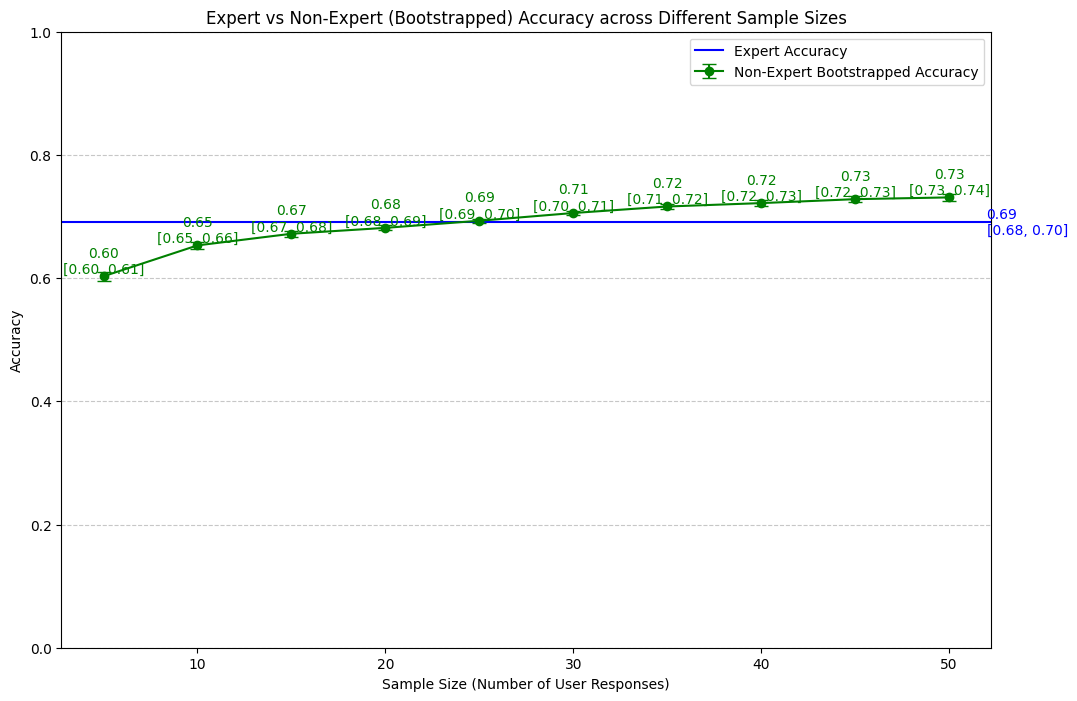

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import random
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

# Assuming df is your DataFrame
# Step 1: Stratify by expert level
experts = df[df['experience_level'] == 'Expert']
non_experts = df[df['experience_level'] != 'Expert']

def compute_majority_accuracy(data):
    # Step 2: Compute majority vote and correctness
    majority_answer = data.groupby('problem_id').apply(
        lambda x: (x.groupby('title')['combinedaccuracy'].sum()).idxmax()
    )
    correct_answers = data.groupby('problem_id')['goldstandardnew'].first()
    majority_correct = (majority_answer == correct_answers).fillna(False)

    # Step 3: Calculate accuracy and 95% CI
    accuracy = majority_correct.mean()
    n = data['problem_id'].nunique()  # Total problems evaluated
    se = np.sqrt(accuracy * (1 - accuracy) / n)
    ci = stats.norm.interval(0.95, loc=accuracy, scale=se)

    return accuracy, ci

# Compute for experts
expert_accuracy, expert_ci = compute_majority_accuracy(experts)

# Step 2: Sensitivity analysis for non-experts
def bootstrap_majority_accuracy(data, sample_size, n_bootstrap=10):
    problem_ids = data['problem_id'].unique()
    bootstrapped_accuracies = []

    def bootstrap_iteration(_):
        sampled_data_list = []

        for pid in problem_ids:
            filtered_data = data[data['problem_id'] == pid]
            if filtered_data['user_id'].nunique() > sample_size:
                sampled_users = random.sample(list(filtered_data['user_id'].unique()), sample_size)
                sampled_data_list.append(filtered_data[filtered_data['user_id'].isin(sampled_users)])

        if sampled_data_list:
            sampled_data = pd.concat(sampled_data_list)
            accuracy, _ = compute_majority_accuracy(sampled_data)
            return accuracy
        return None

    bootstrapped_accuracies = Parallel(n_jobs=-1)(delayed(bootstrap_iteration)(_) for _ in tqdm(range(n_bootstrap), desc="Bootstrapping"))

    # Filter out None values if any
    bootstrapped_accuracies = [acc for acc in bootstrapped_accuracies if acc is not None]

    # Calculate the average accuracy over the bootstrap samples
    avg_bootstrap_accuracy = np.mean(bootstrapped_accuracies)

    # Calculate the 95% confidence interval using percentiles
    lower_bound = np.percentile(bootstrapped_accuracies, 2.5)
    upper_bound = np.percentile(bootstrapped_accuracies, 97.5)
    ci_bootstrap = (lower_bound, upper_bound)

    return avg_bootstrap_accuracy, ci_bootstrap

# Sample sizes to evaluate
sample_sizes = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

# Store results for plotting
non_expert_accuracies = []
non_expert_cis = []

for sample_size in tqdm(sample_sizes, desc="Processing Sample Sizes"):
    non_expert_accuracy, non_expert_ci = bootstrap_majority_accuracy(non_experts, sample_size, n_bootstrap=1000)
    non_expert_accuracies.append(non_expert_accuracy)
    non_expert_cis.append(non_expert_ci)

# Visualization
plt.figure(figsize=(12, 8))

# Plot expert accuracy (horizontal line)
plt.axhline(y=expert_accuracy, color='blue', linestyle='-', label='Expert Accuracy')
plt.text(x=sample_sizes[-1] + 2, y=expert_accuracy,
         s=f'{expert_accuracy:.2f}\n[{expert_ci[0]:.2f}, {expert_ci[1]:.2f}]',
         color='blue', va='center')

# Plot non-expert accuracies with error bars
lower_errors = [acc - ci[0] for acc, ci in zip(non_expert_accuracies, non_expert_cis)]
upper_errors = [ci[1] - acc for acc, ci in zip(non_expert_accuracies, non_expert_cis)]
yerr = [lower_errors, upper_errors]

plt.errorbar(sample_sizes, non_expert_accuracies,
             yerr=yerr, fmt='o-', color='green', capsize=5, label='Non-Expert Bootstrapped Accuracy')

# Annotate non-expert points
for i, (x, y, ci) in enumerate(zip(sample_sizes, non_expert_accuracies, non_expert_cis)):
    plt.text(x, y, f'{y:.2f}\n[{ci[0]:.2f}, {ci[1]:.2f}]', ha='center', va='bottom', color='green')

plt.ylim(0, 1)  # Start y-axis at 0
plt.xlabel('Sample Size (Number of User Responses)')
plt.ylabel('Accuracy')
plt.title('Expert vs Non-Expert (Bootstrapped) Accuracy across Different Sample Sizes')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.show()


In [ ]:
bootstrap_results = pd.DataFrame({
    'sample_size': sample_sizes,
    'non_expert_accuracy': non_expert_accuracies,
    'non_expert_ci_lower': [ci[0] for ci in non_expert_cis],
    'non_expert_ci_upper': [ci[1] for ci in non_expert_cis]
})

# Save the DataFrame to a CSV file
file_path = '/content/drive/MyDrive/Colab Notebooks/bootstrap_accuracy_results.csv'
bootstrap_results.to_csv(file_path, index=False)
print("Bootstrap results have been saved to 'bootstrap_accuracy_results.csv'.")

Bootstrap results have been saved to 'bootstrap_accuracy_results.csv'.


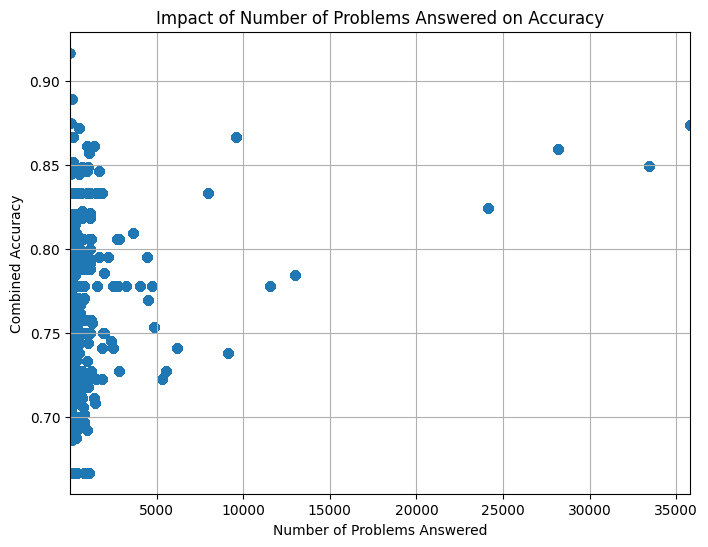

In [ ]:
# Edilberto Amorim 2
import matplotlib.pyplot as plt

# Assume df is already defined with columns: user_id, problem_id, combinedaccuracy
df_unique = df[['user_id', 'combinedaccuracy']]

# Count the number of problems answered by each user
problem_count = df.groupby('user_id')['problem_id'].count().reset_index()
problem_count.rename(columns={'problem_id': 'problems_answered'}, inplace=True)

# Merge the data to associate each user's combined accuracy with their problem count
user_stats = pd.merge(problem_count, df_unique, on='user_id')

# Filter users who answered more than 1 problem
user_stats = user_stats[user_stats['problems_answered'] > 1]

# Plot the data
plt.figure(figsize=(8, 6))
plt.scatter(user_stats['problems_answered'], user_stats['combinedaccuracy'], alpha=0.7)

# Add labels and title
plt.xlabel('Number of Problems Answered')
plt.ylabel('Combined Accuracy')
plt.title('Impact of Number of Problems Answered on Accuracy')

# Set x-axis to start at 1
plt.xlim(1, user_stats['problems_answered'].max())
plt.grid(True)
plt.show()


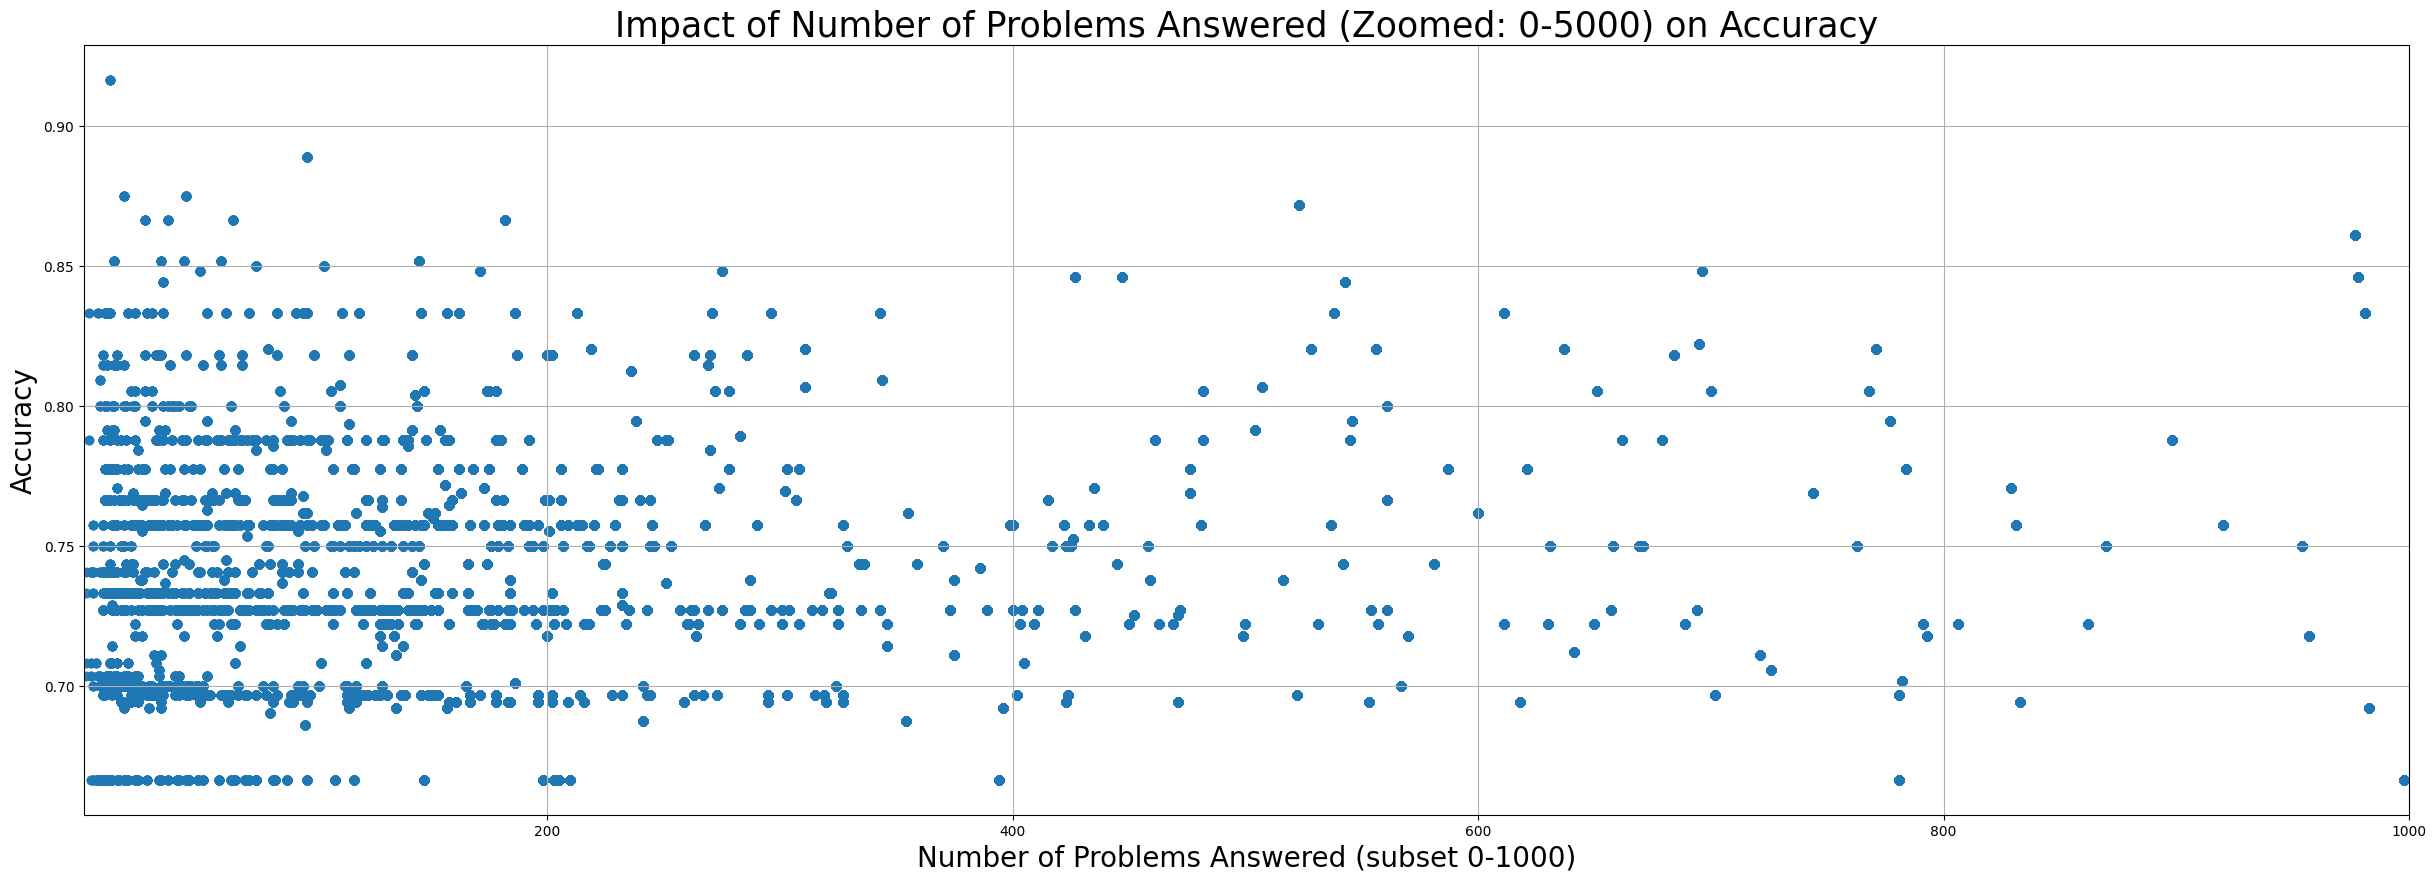

In [ ]:
# Filter and subset data
user_stats_filtered = user_stats[user_stats['problems_answered'] > 0]
subset = user_stats_filtered[user_stats_filtered['problems_answered'] <= 5000]

# Plot the zoomed-in data
plt.figure(figsize=(30, 10))
plt.scatter(subset['problems_answered'], subset['combinedaccuracy'], alpha=0.7)

# Add labels and title with larger fonts
plt.xlabel('Number of Problems Answered (subset 0-1000)', fontsize=20)  # Increase font size
plt.ylabel('Accuracy', fontsize=20)  # Increase font size
plt.title('Impact of Number of Problems Answered (Zoomed: 0-5000) on Accuracy', fontsize=25)  # Larger title
plt.xlim(1, 1000)
plt.grid(True)
plt.show()

In [ ]:
correlation = user_stats['problems_answered'].corr(user_stats['combinedaccuracy'])
print(f"Correlation between problems answered and combined accuracy: {correlation}")

Correlation between problems answered and combined accuracy: 0.7476705865395945


In [ ]:
import numpy as np
import pandas as pd

# Define bins and labels for the problem count ranges.
bins = [1, 1000, 2000, np.inf]
labels = ['1-1000', '1000-2000', '>2000']

# Create a new column in user_stats that categorizes participants based on problems answered.
user_stats['answered_bin'] = pd.cut(user_stats['problems_answered'], bins=bins, labels=labels, right=True)

# Group by the bins and compute summary statistics for combinedaccuracy.
agg_stats = user_stats.groupby('answered_bin')['combinedaccuracy'].agg(
    min_accuracy='min',
    max_accuracy='max',
    mean_accuracy='mean',
    median_accuracy='median'
).reset_index()

print("Combined Accuracy Ranges by Number of Problems Answered:")
print(agg_stats)


Combined Accuracy Ranges by Number of Problems Answered:
  answered_bin  min_accuracy  max_accuracy  mean_accuracy  median_accuracy
0       1-1000      0.666667      0.916667       0.747627         0.743590
1    1000-2000      0.666667      0.861111       0.774006         0.777778
2        >2000      0.722222      0.873874       0.816794         0.824074


<ipython-input-7-2f69d90435c3>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_stats = user_stats.groupby('answered_bin')['combinedaccuracy'].agg(


In [ ]:
your_path = "/content/drive/MyDrive/Colab Notebooks/For JJ- code for figures "

import pathlib
import tempfile

import google.colab
import nbformat
import nbconvert

def download_html(drive_path, mount_dir="/content/drive/"):
  drive_path = pathlib.Path(drive_path)
  notebook_path = pathlib.Path(mount_dir) / 'MyDrive' / drive_path

  # open notebook
  with open(notebook_path) as f:
    notebook = nbformat.reads(f.read(), as_version=nbformat.NO_CONVERT)

  # export to HTML string
  html_exporter = nbconvert.HTMLExporter(template_name = 'classic')
  html, _resources = html_exporter.from_notebook_node(notebook)

  # write and download tmp_file

  tmp_html = (pathlib.Path('/tmp/') / drive_path.name).with_suffix(".html")
  with open(tmp_html, "w") as tmp:
    tmp.write(html)

  google.colab.files.download(tmp_html)

google.colab.drive.mount("/content/drive/")
download_html(your_path)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Assume df is your DataFrame with columns:
# 'user_id', 'problem_id', 'title' (user answer), 'goldstandardnew' (correct answer), 'experience_level'

# Create a binary outcome: 1 if the user's answer matches the gold standard, 0 otherwise.
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)

# Aggregate the data by problem_id and experience_level to compute the proportion correct (accuracy)
agg_df = df.groupby(['problem_id', 'experience_level']).agg({
    'correct': ['mean', 'count']
}).reset_index()

# Flatten the column names
agg_df.columns = ['problem_id', 'experience_level', 'accuracy', 'n']

# For the purpose of the model, ensure experience_level is coded as a categorical variable.
agg_df['experience_level'] = agg_df['experience_level'].astype('category')

# Fit a linear mixed-effects model:
# Here, we model the aggregated accuracy as a function of experience_level (Expert vs. Non-Expert)
# and include a random intercept for problem_id to account for between-problem variability.
model = smf.mixedlm("accuracy ~ experience_level", agg_df, groups=agg_df["problem_id"])
result = model.fit()

print(result.summary())


                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          accuracy   
No. Observations:            56018            Method:                      REML       
No. Groups:                  8894             Scale:                       0.0797     
Min. group size:             3                Log-Likelihood:              -15874.4842
Max. group size:             12               Converged:                   Yes        
Mean group size:             6.3                                                      
--------------------------------------------------------------------------------------
                                             Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                    0.221    0.021 10.653 0.000  0.180  0.261
experience_level[T.Expert]                   0.462    0.021 22.065 0

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Assume df is your DataFrame with the following columns:
# 'user_id', 'problem_id', 'title' (user answer), 'goldstandardnew' (correct answer),
# 'experience_level'

# Create a binary outcome variable: 1 if the user's answer is correct, 0 otherwise.
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)

# Compute the number of unique problems answered per user
df['user_question_count'] = df.groupby('user_id')['problem_id'].transform('nunique')

# Aggregate the data by problem_id and experience_level.
# For each EEG clip (problem_id) and for each experience group, compute:
# - accuracy: mean of 'correct'
# - n: number of responses
# - user_question_count: average number of questions answered (per user in that group)
agg_df = df.groupby(['problem_id', 'experience_level']).agg({
    'correct': ['mean', 'count'],
    'user_question_count': 'mean'
}).reset_index()

# Flatten the multi-level column names.
agg_df.columns = ['problem_id', 'experience_level', 'accuracy', 'n', 'user_question_count']

# Ensure that experience_level is treated as a categorical variable.
agg_df['experience_level'] = agg_df['experience_level'].astype('category')

# Fit a linear mixed-effects model where:
# - The dependent variable is the aggregated accuracy (proportion correct).
# - Fixed effects include experience_level and user_question_count.
# - A random intercept is included for problem_id to account for variability between EEG clips.
model = smf.mixedlm("accuracy ~ experience_level + user_question_count", agg_df, groups=agg_df["problem_id"])
result = model.fit()

print(result.summary())


                        Mixed Linear Model Regression Results
Model:                       MixedLM          Dependent Variable:          accuracy   
No. Observations:            56018            Method:                      REML       
No. Groups:                  8894             Scale:                       0.0779     
Min. group size:             3                Log-Likelihood:              -15399.9066
Max. group size:             12               Converged:                   Yes        
Mean group size:             6.3                                                      
--------------------------------------------------------------------------------------
                                             Coef. Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                    0.214    0.021 10.445 0.000  0.174  0.254
experience_level[T.Expert]                   0.366    0.021 17.512 0

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Assume df is your DataFrame with the following columns:
# 'user_id', 'problem_id', 'title' (user answer), 'goldstandardnew' (correct answer),
# 'experience_level'

# Create a binary outcome variable: 1 if the user's answer is correct, 0 otherwise.
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)

# Create a binary indicator variable: "Expert" if experience_level is 'Expert', otherwise "Non-Expert".
df['group'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Non-Expert')

# Compute the number of unique problems answered per user.
df['user_question_count'] = df.groupby('user_id')['problem_id'].transform('nunique')

# Aggregate the data by problem_id and group.
# For each EEG clip (problem_id) and for each group, compute:
# - accuracy: mean of 'correct'
# - n: number of responses
# - user_question_count: average number of questions answered (per user in that group)
agg_df = df.groupby(['problem_id', 'group']).agg({
    'correct': ['mean', 'count'],
    'user_question_count': 'mean'
}).reset_index()

# Flatten the multi-level column names.
agg_df.columns = ['problem_id', 'group', 'accuracy', 'n', 'user_question_count']

# Ensure that 'group' is treated as a categorical variable.
agg_df['group'] = agg_df['group'].astype('category')

# Fit a linear mixed-effects model:
# - Dependent variable: aggregated accuracy (proportion correct).
# - Fixed effects: group (Expert vs. Non-Expert) and user_question_count.
# - Random effect: problem_id (to account for variability across EEG clips).
model = smf.mixedlm("accuracy ~ group + user_question_count", agg_df, groups=agg_df["problem_id"])
result = model.fit()

print(result.summary())


             Mixed Linear Model Regression Results
Model:               MixedLM   Dependent Variable:   accuracy  
No. Observations:    14775     Method:               REML      
No. Groups:          8894      Scale:                0.0704    
Min. group size:     1         Log-Likelihood:       -4505.5172
Max. group size:     2         Converged:            Yes       
Mean group size:     1.7                                       
---------------------------------------------------------------
                    Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept            0.643    0.008  79.943 0.000  0.627  0.659
group[T.Non-Expert] -0.221    0.005 -41.457 0.000 -0.232 -0.211
user_question_count  0.000    0.000   5.791 0.000  0.000  0.000
Group Var            0.044    0.007                            



        group      mean       std  count        se        ci
0      Expert  0.682511  0.440258   5881  0.005741  0.011252
1  Non-Expert  0.476589  0.254395   8894  0.002697  0.005287


<ipython-input-34-221f314e348e>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_summary = agg_df.groupby('group')['accuracy'].agg(['mean', 'std', 'count']).reset_index()


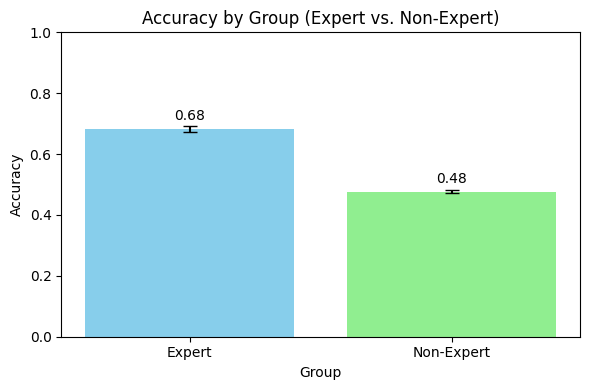

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Aggregate summary statistics for each group.
group_summary = agg_df.groupby('group')['accuracy'].agg(['mean', 'std', 'count']).reset_index()
group_summary['se'] = group_summary['std'] / np.sqrt(group_summary['count'])
group_summary['ci'] = 1.96 * group_summary['se']

print(group_summary)

# Create the bar graph.
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(group_summary['group'], group_summary['mean'],
              yerr=group_summary['ci'], capsize=5, color=['skyblue', 'lightgreen'])

ax.set_xlabel('Group')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Group (Expert vs. Non‑Expert)')
ax.set_ylim(0, 1)  # Accuracy is a proportion between 0 and 1

# Annotate the bars with the mean accuracy value.
for i, row in group_summary.iterrows():
    ax.text(i, row['mean'] + 0.02, f"{row['mean']:.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


Overall Non-Inferiority Test (Non-Expert - Expert):
  Difference (Non-Expert - Expert): -0.221
  Standard Error: 0.005
  95% CI: [-0.232, -0.211]
  Z-statistic: -32.087
  One-sided p-value: 0.0000


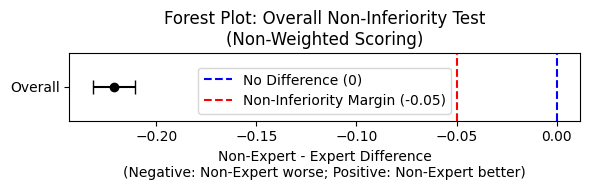

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Set non-inferiority margin (delta).
# Now, using Non-Expert - Expert differences, the non-inferiority margin becomes -0.05.
delta = -0.05

# Extract the coefficient and its standard error for the group effect.
# In the fitted model, the baseline is "Expert", so the coefficient for group[T.Non-Expert]
# equals (Non-Expert - Expert).
diff_overall = result.params["group[T.Non-Expert]"]
se_overall = np.sqrt(result.cov_params().loc["group[T.Non-Expert]", "group[T.Non-Expert]"])

# Compute the 95% confidence interval for the difference.
lower = diff_overall - 1.96 * se_overall
upper = diff_overall + 1.96 * se_overall

# Compute the z statistic and one-sided p-value for non-inferiority:
# H0: Non-Expert - Expert < -0.05  vs.  H1: Non-Expert - Expert >= -0.05.
z = (diff_overall - delta) / se_overall
p_value = norm.cdf(z)

print("Overall Non-Inferiority Test (Non-Expert - Expert):")
print(f"  Difference (Non-Expert - Expert): {diff_overall:.3f}")
print(f"  Standard Error: {se_overall:.3f}")
print(f"  95% CI: [{lower:.3f}, {upper:.3f}]")
print(f"  Z-statistic: {z:.3f}")
print(f"  One-sided p-value: {p_value:.4f}")

# Create a forest plot for the overall non-inferiority result.
fig, ax = plt.subplots(figsize=(6, 2))

# Plot the overall effect as a point with horizontal error bars.
ax.errorbar(diff_overall, 0,
            xerr=[[diff_overall - lower], [upper - diff_overall]],
            fmt='o', color='black', capsize=5)

# Draw vertical lines for interpretation:
# A blue dashed line at 0 represents "no difference" (Non-Expert = Expert).
ax.axvline(x=0, color='blue', linestyle='--', label='No Difference (0)')
# A red dashed line at -0.05 represents the non-inferiority margin.
ax.axvline(x=delta, color='red', linestyle='--', label=f'Non-Inferiority Margin ({delta})')

# Customize the plot.
ax.set_yticks([0])
ax.set_yticklabels(['Overall'])
ax.set_xlabel("Non-Expert - Expert Difference\n(Negative: Non-Expert worse; Positive: Non-Expert better)")
ax.set_title("Forest Plot: Overall Non-Inferiority Test\n(Non-Weighted Scoring)")
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Assume df is your DataFrame with columns:
# 'user_id', 'problem_id', 'title' (user answer), 'goldstandardnew' (correct answer),
# 'experience_level', and 'combinedaccuracy'

# Drop rows with missing critical data.
df = df.dropna(subset=['user_id', 'problem_id', 'title', 'goldstandardnew', 'experience_level'])

# Create a binary indicator: 1 if the user's answer matches the gold standard, 0 otherwise.
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)

# Create a group variable: "Expert" if experience_level is 'Expert', otherwise "Non-Expert".
df['group'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Non-Expert')

# Compute the number of unique problems answered per user.
df['user_question_count'] = df.groupby('user_id')['problem_id'].transform('nunique')

# Aggregate the data by problem_id, group, and goldstandardnew.
# For each combination, compute the accuracy (mean of 'correct') and the average question count.
agg_df = df.groupby(['problem_id', 'group', 'goldstandardnew'], observed=True, group_keys=False).agg({
    'correct': 'mean',
    'user_question_count': 'mean'
}).reset_index()

# Rename columns for clarity.
agg_df.rename(columns={'correct': 'accuracy', 'user_question_count': 'avg_question_count'}, inplace=True)

# Convert grouping variables to categorical.
agg_df['group'] = agg_df['group'].astype('category')
agg_df['goldstandardnew'] = agg_df['goldstandardnew'].astype('category')

# Fit a linear mixed-effects model:
# - Dependent variable: accuracy (aggregated proportion correct per problem and pattern)
# - Fixed effects: group, goldstandardnew, their interaction, and avg_question_count
# - Random effect: problem_id to account for between-EEG clip variability.
model = smf.mixedlm("accuracy ~ group * goldstandardnew + avg_question_count", agg_df, groups=agg_df["problem_id"])
result = model.fit()

print(result.summary())


                          Mixed Linear Model Regression Results
Model:                        MixedLM            Dependent Variable:            accuracy  
No. Observations:             14775              Method:                        REML      
No. Groups:                   8894               Scale:                         0.0671    
Min. group size:              1                  Log-Likelihood:                -4000.8368
Max. group size:              2                  Converged:                     Yes       
Mean group size:              1.7                                                         
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                       0.748    0.013  59.276 0.000  0.723  0.772
group[T.Non-Expert]       

In [ ]:
import numpy as np
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# Assume 'result' is your fitted mixed-effects model result.
# Extract parameter estimates and their covariance matrix.
params = result.params
cov = result.cov_params()

delta = 0.05  # non-inferiority margin (5%)

# Initialize a dictionary to store results by pattern.
pattern_results = {}

# For the baseline pattern (GPD), no interaction term is present.
# The coefficient for group[T.Non-Expert] is (Non-Expert - Expert) for GPD.
diff_gpd = -params['group[T.Non-Expert]']  # Expert - Non-Expert difference for GPD
se_gpd = np.sqrt(cov.loc['group[T.Non-Expert]', 'group[T.Non-Expert]'])
z_gpd = (diff_gpd - delta) / se_gpd
p_gpd = norm.cdf(z_gpd)  # one-sided p-value

pattern_results['gpd'] = {'difference': diff_gpd, 'se': se_gpd, 'z': z_gpd, 'p_value': p_gpd}

# Loop through other patterns by checking interaction terms.
# Interaction term names have the format "group[T.Non-Expert]:goldstandardnew[T.<pattern>]"
for param_name in params.index:
    if param_name.startswith("group[T.Non-Expert]:goldstandardnew[T."):
        # Extract the pattern name from the parameter.
        pattern = param_name.split("group[T.Non-Expert]:goldstandardnew[T.")[1].rstrip("]")
        # The overall difference for this pattern is the sum of the baseline difference and the interaction.
        diff_pattern = -params['group[T.Non-Expert]'] + params[param_name]

        # Calculate the standard error for the combined difference.
        var_baseline = cov.loc['group[T.Non-Expert]', 'group[T.Non-Expert]']
        var_inter = cov.loc[param_name, param_name]
        covar = cov.loc['group[T.Non-Expert]', param_name]
        se_pattern = np.sqrt(var_baseline + var_inter + 2 * covar)

        z_pattern = (diff_pattern - delta) / se_pattern
        p_pattern = norm.cdf(z_pattern)

        pattern_results[pattern] = {
            'difference': diff_pattern,
            'se': se_pattern,
            'z': z_pattern,
            'p_value': p_pattern
        }

# --- Adjust p-values for multiple testing (Bonferroni correction) ---
# Collect all p-values
p_values = [res['p_value'] for res in pattern_results.values()]

# Apply Bonferroni correction using statsmodels' multipletests.
# This returns a boolean array for rejection, the adjusted p-values, and additional info.
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# Update pattern_results with adjusted p-values.
for i, key in enumerate(pattern_results.keys()):
    pattern_results[key]['adjusted_p_value'] = pvals_corrected[i]

# --- Print the results ---
for pat, res in pattern_results.items():
    print(f"Pattern: {pat}")
    print(f"  Expert - Non-Expert Difference: {res['difference']:.3f}")
    print(f"  Standard Error: {res['se']:.3f}")
    print(f"  Z-Statistic: {res['z']:.3f}")
    print(f"  One-sided p-value (non-inferiority, delta=0.05): {res['p_value']:.4f}")
    print(f"  Adjusted p-value (Bonferroni): {res['adjusted_p_value']:.4f}\n")


Pattern: gpd
  Expert - Non-Expert Difference: 0.223
  Standard Error: 0.012
  Z-Statistic: 13.968
  One-sided p-value (non-inferiority, delta=0.05): 1.0000
  Adjusted p-value (Bonferroni): 1.0000

Pattern: grda
  Expert - Non-Expert Difference: 0.243
  Standard Error: 0.013
  Z-Statistic: 15.257
  One-sided p-value (non-inferiority, delta=0.05): 1.0000
  Adjusted p-value (Bonferroni): 1.0000

Pattern: lpd
  Expert - Non-Expert Difference: 0.183
  Standard Error: 0.011
  Z-Statistic: 11.660
  One-sided p-value (non-inferiority, delta=0.05): 1.0000
  Adjusted p-value (Bonferroni): 1.0000

Pattern: lrda
  Expert - Non-Expert Difference: 0.225
  Standard Error: 0.014
  Z-Statistic: 12.333
  One-sided p-value (non-inferiority, delta=0.05): 1.0000
  Adjusted p-value (Bonferroni): 1.0000

Pattern: other
  Expert - Non-Expert Difference: 0.124
  Standard Error: 0.010
  Z-Statistic: 7.539
  One-sided p-value (non-inferiority, delta=0.05): 1.0000
  Adjusted p-value (Bonferroni): 1.0000

Pattern

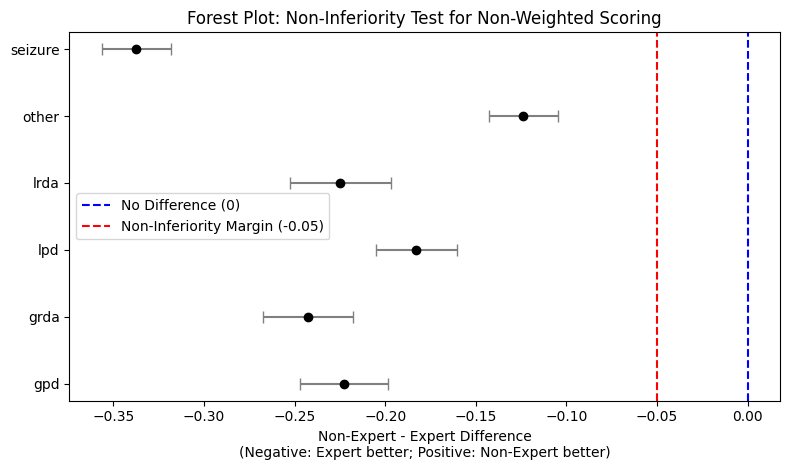

In [ ]:
import matplotlib.pyplot as plt

# Adjust pattern names: for example, rename 'baseline' to 'gpd' if needed.
orig_patterns = list(pattern_results.keys())
patterns = ['gpd' if p == 'baseline' else p for p in orig_patterns]

# Extract the Expert – Non-Expert differences and standard errors.
# (These differences were computed as Expert - Non-Expert.)
orig_differences = [pattern_results[p]['difference'] for p in orig_patterns]
ses = [pattern_results[p]['se'] for p in orig_patterns]

# Convert to Non-Expert - Expert differences (so that negative values mean Experts are better,
# and positive values indicate Non-Experts are better).
differences = [-d for d in orig_differences]

# Compute the 95% confidence intervals for the original differences.
ci_lower_orig = [d - 1.96 * se for d, se in zip(orig_differences, ses)]
ci_upper_orig = [d + 1.96 * se for d, se in zip(orig_differences, ses)]
# For Non-Expert - Expert differences, reverse the bounds:
ci_lower = [-upper for upper in ci_upper_orig]  # new lower bound
ci_upper = [-lower for lower in ci_lower_orig]  # new upper bound

# Create the forest plot.
fig, ax = plt.subplots(figsize=(8, len(patterns) * 0.8))
ax.errorbar(differences, range(len(patterns)),
            xerr=[ [diff - low for diff, low in zip(differences, ci_lower)],
                   [up - diff for diff, up in zip(differences, ci_upper)] ],
            fmt='o', color='black', ecolor='gray', capsize=4)

# Define the margins.
# The no difference (superiority) margin is at 0.
ax.axvline(x=0, color='blue', linestyle='--', label='No Difference (0)')
# The non-inferiority margin is at -0.05 (i.e. if the entire CI is above -0.05,
# the non-expert is considered non-inferior to the expert).
ax.axvline(x=-0.05, color='red', linestyle='--', label='Non-Inferiority Margin (-0.05)')

# Customize the plot.
ax.set_yticks(range(len(patterns)))
ax.set_yticklabels(patterns)
ax.set_xlabel("Non-Expert - Expert Difference\n(Negative: Expert better; Positive: Non-Expert better)")
ax.set_title("Forest Plot: Non-Inferiority Test for Non-Weighted Scoring")
ax.legend()
plt.tight_layout()
plt.show()


<ipython-input-28-cee46bbf2840>:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pattern_group_summary = agg_df.groupby(['goldstandardnew', 'group'])['predicted_accuracy'] \


   goldstandardnew       group      mean       std  count        se        ci
0              gpd      Expert  0.786129  0.021146    836  0.000731  0.001433
1              gpd  Non-Expert  0.586532  0.008645   1420  0.000229  0.000450
2             grda      Expert  0.714764  0.020917    820  0.000730  0.001432
3             grda  Non-Expert  0.535198  0.007586   1242  0.000215  0.000422
4              lpd      Expert  0.630501  0.021391    966  0.000688  0.001349
5              lpd  Non-Expert  0.384792  0.009158   1511  0.000236  0.000462
6             lrda      Expert  0.619545  0.018774    652  0.000735  0.001441
7             lrda  Non-Expert  0.421043  0.007514    886  0.000252  0.000495
8            other      Expert  0.636897  0.021271   1311  0.000587  0.001151
9            other  Non-Expert  0.328155  0.011152   1942  0.000253  0.000496
10         seizure      Expert  0.706181  0.020863   1296  0.000580  0.001136
11         seizure  Non-Expert  0.607212  0.010410   1893  0.000

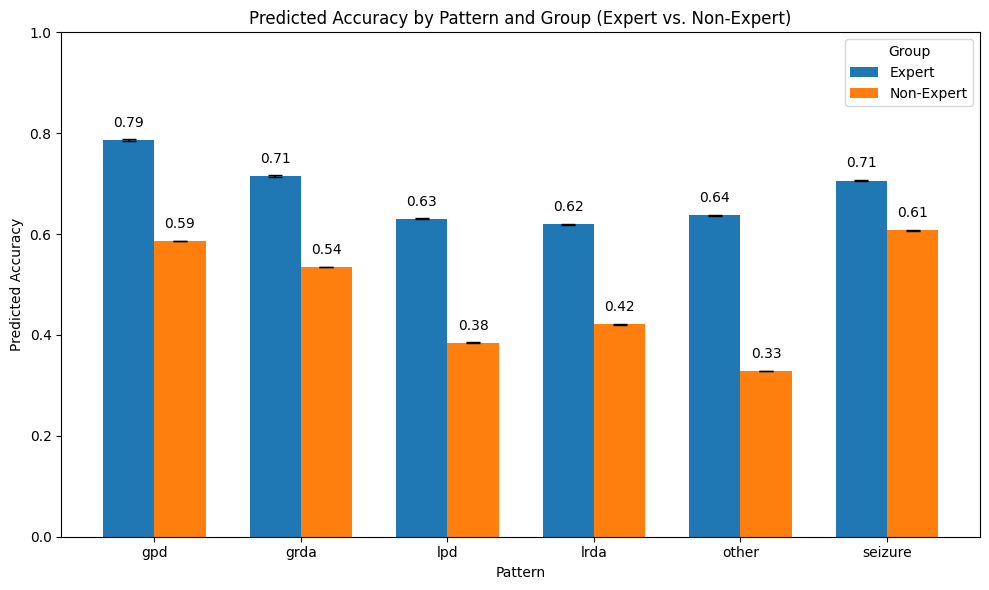

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# First, compute predicted accuracy for each observation using your fitted model.
agg_df['predicted_accuracy'] = result.predict(agg_df)

# Now compute summary statistics by pattern and group.
pattern_group_summary = agg_df.groupby(['goldstandardnew', 'group'])['predicted_accuracy'] \
    .agg(['mean', 'std', 'count']).reset_index()
pattern_group_summary['se'] = pattern_group_summary['std'] / np.sqrt(pattern_group_summary['count'])
pattern_group_summary['ci'] = 1.96 * pattern_group_summary['se']

print(pattern_group_summary)

# Get unique patterns and groups.
patterns = pattern_group_summary['goldstandardnew'].unique()
groups = pattern_group_summary['group'].unique()

# Create positions for the grouped bars.
x = np.arange(len(patterns))  # one position per pattern on the x-axis
width = 0.35  # width for each group bar

fig, ax = plt.subplots(figsize=(10, 6))

# Plot a bar for each group within each pattern.
for i, grp in enumerate(groups):
    # Filter data for the current group.
    grp_data = pattern_group_summary[pattern_group_summary['group'] == grp]
    # Ensure the order is the same as in 'patterns'.
    grp_data = grp_data.set_index('goldstandardnew').loc[patterns].reset_index()

    # Position each group's bar.
    pos = x - width/2 + i * width
    bars = ax.bar(pos, grp_data['mean'], width, yerr=grp_data['ci'], capsize=5,
                  label=grp)

    # Annotate each bar with the mean predicted accuracy.
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

# Customize the plot.
ax.set_xticks(x)
ax.set_xticklabels(patterns)
ax.set_xlabel("Pattern")
ax.set_ylabel("Predicted Accuracy")
ax.set_title("Predicted Accuracy by Pattern and Group (Expert vs. Non‑Expert)")
ax.set_ylim(0, 1)
ax.legend(title="Group")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Assume df is your DataFrame with columns:
# 'user_id', 'problem_id', 'title' (user answer), 'goldstandardnew' (correct answer),
# 'experience_level', 'combinedaccuracy'

# Create a binary indicator for correctness at the individual response level (for other uses if needed)
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)

# Create a group variable: Expert vs. Crowd (Non-Expert)
df['group'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Crowd')

# Compute the number of unique questions answered per user.
df['user_question_count'] = df.groupby('user_id')['problem_id'].transform('nunique')

# Define a function to compute the weighted majority prediction for a single problem (subset)
def compute_weighted_accuracy(sub_df):
    # Compute the weighted sum of combinedaccuracy for each candidate answer.
    pred = sub_df.groupby('title')['combinedaccuracy'].sum().idxmax()
    # Assume the gold standard is constant within the problem.
    gold = sub_df['goldstandardnew'].iloc[0]
    # Return 1 if prediction matches the gold standard, 0 otherwise.
    return int(pred == gold)

# Aggregate the data by problem_id and group.
# For each problem and group, compute:
# - weighted_accuracy: the binary outcome from the weighted majority vote.
# - avg_question_count: the mean number of questions answered (user_question_count) for users in that group.
agg_df = df.groupby(['problem_id', 'group']).apply(
    lambda sub_df: pd.Series({
        'weighted_accuracy': compute_weighted_accuracy(sub_df),
        'avg_question_count': sub_df['user_question_count'].mean()
    })
).reset_index()

print(agg_df.head())

# Fit a linear mixed-effects model using the aggregated weighted accuracy as the dependent variable.
# Fixed effects: group (Expert vs. Crowd) and avg_question_count.
# Random effect: problem_id (to account for between-clip variability).
model = smf.mixedlm("weighted_accuracy ~ group + avg_question_count", agg_df, groups=agg_df["problem_id"])
result = model.fit()

print(result.summary())


<ipython-input-49-8761ea170eca>:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_df = df.groupby(['problem_id', 'group']).apply(


   problem_id   group  weighted_accuracy  avg_question_count
0     4958127   Crowd                1.0         6706.321429
1     4958127  Expert                1.0         1037.000000
2     4958129   Crowd                1.0         7047.000000
3     4958130   Crowd                0.0         7250.095238
4     4958130  Expert                1.0         4187.000000
             Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: weighted_accuracy
No. Observations: 14775   Method:             REML             
No. Groups:       8894    Scale:              0.1267           
Min. group size:  1       Log-Likelihood:     -9027.0029       
Max. group size:  2       Converged:          Yes              
Mean group size:  1.7                                          
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Interce

    group      mean       std  count        se        ci
0   Crowd  0.698898  0.458763   8894  0.004865  0.009534
1  Expert  0.684237  0.464858   5881  0.006062  0.011881


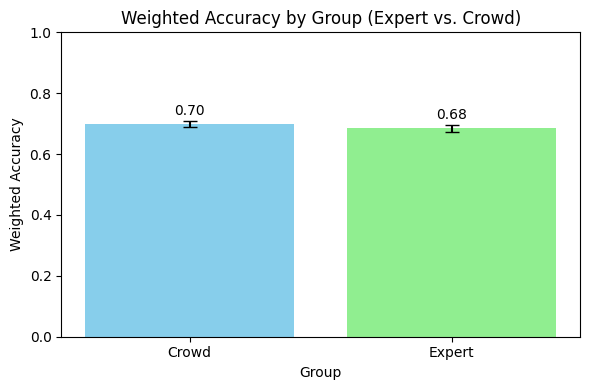

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Aggregate summary statistics for each group.
group_summary = agg_df.groupby('group')['weighted_accuracy'].agg(['mean', 'std', 'count']).reset_index()
group_summary['se'] = group_summary['std'] / np.sqrt(group_summary['count'])
group_summary['ci'] = 1.96 * group_summary['se']

print(group_summary)

# Create the bar graph.
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(group_summary['group'], group_summary['mean'],
              yerr=group_summary['ci'], capsize=5,
              color=['skyblue', 'lightgreen'])

ax.set_xlabel('Group')
ax.set_ylabel('Weighted Accuracy')
ax.set_title('Weighted Accuracy by Group (Expert vs. Crowd)')
ax.set_ylim(0, 1)

# Annotate the bars with the mean accuracy value.
for i, row in group_summary.iterrows():
    ax.text(i, row['mean'] + 0.02, f"{row['mean']:.2f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from scipy.stats import norm

# Set your non-inferiority margin.
delta = 0.05

# Extract the coefficient and standard error for the Expert group.
# (Assuming 'Crowd' is the baseline and the parameter is named "group[T.Expert]").
diff_expert_vs_crowd = result.params["group[T.Expert]"]  # Expert - Crowd difference
se_diff = np.sqrt(result.cov_params().loc["group[T.Expert]", "group[T.Expert]"])

# Compute the z statistic for non-inferiority:
z = (diff_expert_vs_crowd - delta) / se_diff

# One-sided p-value (using the lower tail).
p_value = norm.cdf(z)

print("Non-inferiority test (Expert - Crowd):")
print(f"  Difference (Expert - Crowd): {diff_expert_vs_crowd:.3f}")
print(f"  Standard Error: {se_diff:.3f}")
print(f"  Z-statistic: {z:.3f}")
print(f"  One-sided non-inferiority p-value: {p_value:.4f}")


Non-inferiority test (Expert - Crowd):
  Difference (Expert - Crowd): -0.004
  Standard Error: 0.007
  Z-statistic: -7.585
  One-sided non-inferiority p-value: 0.0000


In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Assume df is your DataFrame with columns:
# 'user_id', 'problem_id', 'title' (user answer), 'goldstandardnew' (correct answer),
# 'experience_level', and 'combinedaccuracy'

# Create a binary indicator for correctness at the individual level if needed (for other purposes)
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)

# Create a group variable for Expert vs. Crowd (Non-Expert)
df['group'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Crowd')

# Compute the number of unique problems answered per user.
df['user_question_count'] = df.groupby('user_id')['problem_id'].transform('nunique')

# Define a function to compute the weighted majority prediction for each problem.
def compute_weighted_accuracy(sub_df):
    # Sum the combinedaccuracy for each candidate answer (title) and select the one with the highest total.
    predicted = sub_df.groupby('title')['combinedaccuracy'].sum().idxmax()
    # Assume that goldstandardnew is constant within each problem.
    gold = sub_df['goldstandardnew'].iloc[0]
    # Return 1 if the weighted prediction matches the gold standard, 0 otherwise.
    return int(predicted == gold)

# Aggregate the data by problem_id, group, and goldstandardnew.
# For each problem and group, compute:
#   - weighted_accuracy: binary outcome from the weighted majority vote.
#   - avg_question_count: the average number of unique questions answered by users in that subgroup.
agg_df = df.groupby(['problem_id', 'group', 'goldstandardnew']).apply(
    lambda sub_df: pd.Series({
        'weighted_accuracy': compute_weighted_accuracy(sub_df),
        'avg_question_count': sub_df['user_question_count'].mean()
    })
).reset_index()

# Ensure that goldstandardnew is treated as a categorical variable.
agg_df['goldstandardnew'] = agg_df['goldstandardnew'].astype('category')

# Fit a linear mixed-effects model:
# - Dependent variable: weighted_accuracy (a proportion: 0 or 1 per problem/group).
# - Fixed effects: group, goldstandardnew, their interaction, and avg_question_count.
# - Random effect: problem_id (to account for variability across EEG clips).
model = smf.mixedlm("weighted_accuracy ~ group * goldstandardnew + avg_question_count",
                    agg_df, groups=agg_df["problem_id"])
result = model.fit()

print(result.summary())


<ipython-input-9-5b1c5ce33c6d>:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_df = df.groupby(['problem_id', 'group', 'goldstandardnew']).apply(


                        Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        weighted_accuracy
No. Observations:          14775          Method:                    REML             
No. Groups:                8894           Scale:                     0.1199           
Min. group size:           1              Log-Likelihood:            -8547.5528       
Max. group size:           2              Converged:                 Yes              
Mean group size:           1.7                                                        
--------------------------------------------------------------------------------------
                                           Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------------------
Intercept                                   0.843    0.018  47.106 0.000  0.808  0.878
group[T.Expert]                            -0.073    0.017  -4.396 0

In [ ]:
import numpy as np
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# Set your non-inferiority margin.
delta = 0.05

# Extract parameter estimates and covariance matrix from the fitted model.
params = result.params
cov = result.cov_params()

# Initialize a dictionary to store results for each pattern.
# The baseline pattern is assumed to be the reference level of goldstandardnew.
pattern_results = {}

# For the baseline pattern (e.g., "GPD"):
if "group[T.Expert]" in params.index:
    diff_baseline = params["group[T.Expert]"]
    se_baseline = np.sqrt(cov.loc["group[T.Expert]", "group[T.Expert]"])
    z_baseline = (diff_baseline - delta) / se_baseline
    p_baseline = norm.cdf(z_baseline)  # one-sided p-value

    pattern_results['baseline'] = {
        'difference': diff_baseline,
        'se': se_baseline,
        'z': z_baseline,
        'p_value': p_baseline
    }

# Loop through parameters to identify interaction terms.
for param_name in params.index:
    if param_name.startswith("group[T.Expert]:goldstandardnew[T."):
        pattern = param_name.split("group[T.Expert]:goldstandardnew[T.")[1].rstrip("]")

        # Overall difference is baseline plus the interaction effect.
        diff_pattern = params["group[T.Expert]"] + params[param_name]

        # Compute the combined standard error.
        var_baseline = cov.loc["group[T.Expert]", "group[T.Expert]"]
        var_inter = cov.loc[param_name, param_name]
        covar = cov.loc["group[T.Expert]", param_name]
        se_pattern = np.sqrt(var_baseline + var_inter + 2 * covar)

        z_pattern = (diff_pattern - delta) / se_pattern
        p_pattern = norm.cdf(z_pattern)

        pattern_results[pattern] = {
            'difference': diff_pattern,
            'se': se_pattern,
            'z': z_pattern,
            'p_value': p_pattern
        }

# --- Adjust p-values for multiple testing (Bonferroni correction) ---
# Collect all p-values from the results.
p_values = [res['p_value'] for res in pattern_results.values()]

# Apply Bonferroni correction.
reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# Update the pattern_results dictionary with the adjusted p-values.
for i, key in enumerate(pattern_results.keys()):
    pattern_results[key]['adjusted_p_value'] = pvals_corrected[i]

# --- Print the non-inferiority test results for each pattern ---
for pattern, res in pattern_results.items():
    print(f"Pattern: {pattern}")
    print(f"  Expert - Crowd Difference: {res['difference']:.3f}")
    print(f"  Standard Error: {res['se']:.3f}")
    print(f"  Z-Statistic: {res['z']:.3f}")
    print(f"  One-sided Non-Inferiority p-value: {res['p_value']:.4f}")
    print(f"  Adjusted p-value: {res['adjusted_p_value']:.4f}\n")


Pattern: baseline
  Expert - Crowd Difference: -0.073
  Standard Error: 0.017
  Z-Statistic: -7.406
  One-sided Non-Inferiority p-value: 0.0000
  Adjusted p-value: 0.0000

Pattern: grda
  Expert - Crowd Difference: -0.141
  Standard Error: 0.017
  Z-Statistic: -11.289
  One-sided Non-Inferiority p-value: 0.0000
  Adjusted p-value: 0.0000

Pattern: lpd
  Expert - Crowd Difference: 0.035
  Standard Error: 0.015
  Z-Statistic: -1.002
  One-sided Non-Inferiority p-value: 0.1583
  Adjusted p-value: 0.9495

Pattern: lrda
  Expert - Crowd Difference: -0.105
  Standard Error: 0.019
  Z-Statistic: -8.176
  One-sided Non-Inferiority p-value: 0.0000
  Adjusted p-value: 0.0000

Pattern: other
  Expert - Crowd Difference: 0.174
  Standard Error: 0.013
  Z-Statistic: 9.468
  One-sided Non-Inferiority p-value: 1.0000
  Adjusted p-value: 1.0000

Pattern: seizure
  Expert - Crowd Difference: -0.063
  Standard Error: 0.013
  Z-Statistic: -8.666
  One-sided Non-Inferiority p-value: 0.0000
  Adjusted p-va

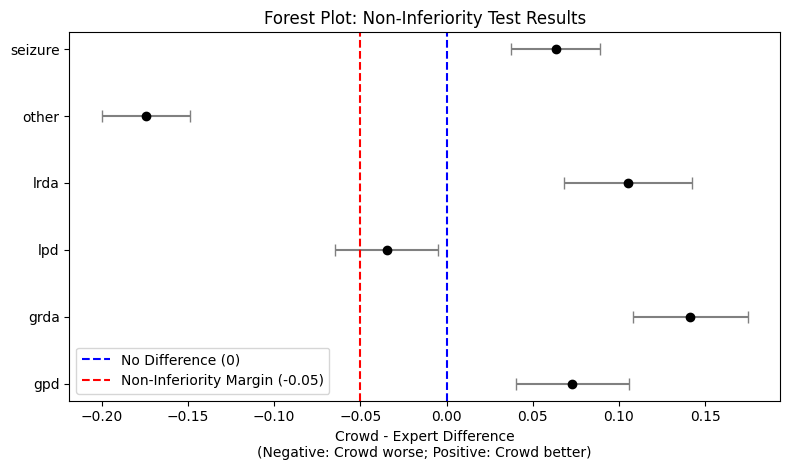

In [ ]:
import matplotlib.pyplot as plt

# Rename baseline if needed.
orig_patterns = list(pattern_results.keys())
patterns = ['gpd' if p == 'baseline' else p for p in orig_patterns]

# Get the original differences and SEs (these were computed as Expert - Crowd).
orig_differences = [pattern_results[p]['difference'] for p in orig_patterns]
ses = [pattern_results[p]['se'] for p in orig_patterns]

# Convert to Crowd - Expert differences by multiplying by -1.
differences = [-d for d in orig_differences]

# Compute original confidence intervals (for Expert - Crowd).
ci_lower_orig = [d - 1.96 * se for d, se in zip(orig_differences, ses)]
ci_upper_orig = [d + 1.96 * se for d, se in zip(orig_differences, ses)]
# For Crowd - Expert, reverse and multiply by -1.
ci_lower = [-upper for upper in ci_upper_orig]
ci_upper = [-lower for lower in ci_lower_orig]

# Create the forest plot.
fig, ax = plt.subplots(figsize=(8, len(patterns) * 0.8))

# Plot the effect sizes and their 95% confidence intervals.
ax.errorbar(differences, range(len(patterns)),
            xerr=[ [d - l for d, l in zip(differences, ci_lower)],
                   [u - d for d, u in zip(differences, ci_upper)] ],
            fmt='o', color='black', ecolor='gray', capsize=4)

# Define the non-inferiority margin.
# For a non-inferiority test (crowd vs. expert) with delta=0.05,
# we want to show that crowd performance is not lower than expert performance by more than 5%.
# When expressed as (Crowd - Expert), the margin is -0.05.
non_inferiority_margin = -0.05

# Plot vertical lines.
ax.axvline(x=0, color='blue', linestyle='--', label='No Difference (0)')
ax.axvline(x=non_inferiority_margin, color='red', linestyle='--',
           label=f'Non-Inferiority Margin ({non_inferiority_margin})')

# Customize the y-axis with the pattern labels.
ax.set_yticks(range(len(patterns)))
ax.set_yticklabels(patterns)
ax.set_xlabel("Crowd - Expert Difference\n(Negative: Crowd worse; Positive: Crowd better)")
ax.set_title("Forest Plot: Non-Inferiority Test Results")

ax.legend()
plt.tight_layout()
plt.show()


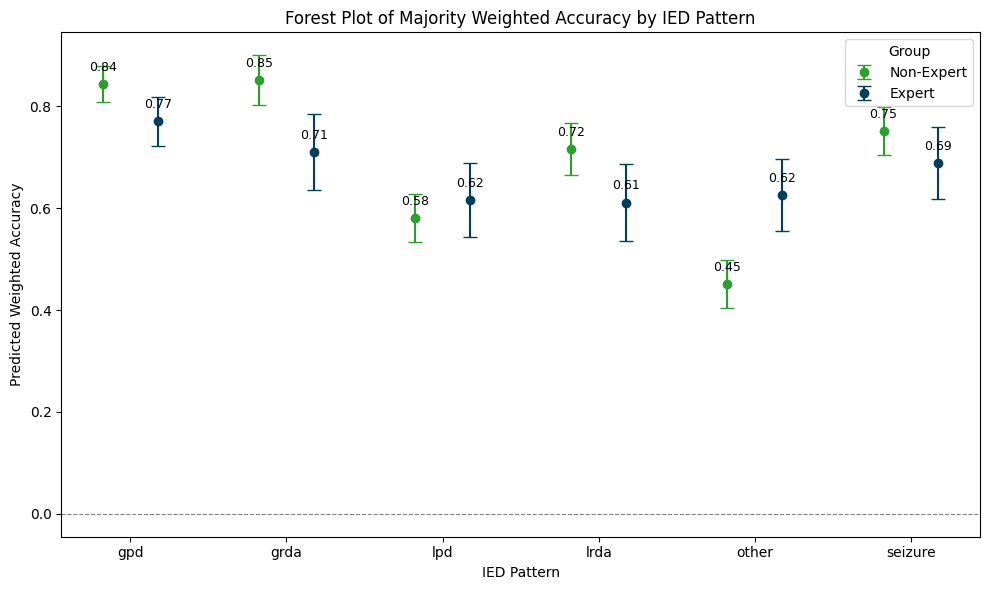

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Example predicted values and standard errors based on the model summary.
# For each pattern, we compute the predicted weighted accuracy as follows:
# For the baseline category (gpd):
#   Non-Expert: Intercept = 0.843
#   Expert: Intercept + group[T.Expert] = 0.843 - 0.073 = 0.770
#
# For other patterns, Non-Expert predictions are:
#   grda: 0.843 + 0.008 = 0.851
#   lpd:  0.843 - 0.262 = 0.581
#   lrda: 0.843 - 0.127 = 0.716
#   other:0.843 - 0.392 = 0.451
#   seizure: 0.843 - 0.092 = 0.751
#
# And Expert predictions are:
#   grda: 0.843 - 0.073 + 0.008 - 0.068 = 0.710
#   lpd:  0.843 - 0.073 - 0.262 + 0.108 = 0.616
#   lrda: 0.843 - 0.073 - 0.127 - 0.032 = 0.611
#   other:0.843 - 0.073 - 0.392 + 0.247 = 0.625
#   seizure: 0.843 - 0.073 - 0.092 + 0.010 = 0.688
#
# We'll also provide approximate SEs (these are illustrative approximations):
# For Non-Expert, use SE = sqrt(SE(Intercept)^2 + SE(goldstandardnew)^2)
# For Expert, use the square root of the sum of squared SEs for intercept, group effect, pattern, and interaction.
# These are approximate:
# gpd: Non-Expert SE = 0.018; Expert SE ≈ 0.025
# grda: Non-Expert SE ≈ 0.025; Expert SE ≈ 0.038
# lpd:  Non-Expert SE ≈ 0.024; Expert SE ≈ 0.037
# lrda: Non-Expert SE ≈ 0.026; Expert SE ≈ 0.039
# other:Non-Expert SE ≈ 0.024; Expert SE ≈ 0.036
# seizure:Non-Expert SE ≈ 0.024; Expert SE ≈ 0.036

# Create a list of dictionaries with our predicted values:
results = [
    {'Pattern': 'gpd', 'Group': 'Non-Expert', 'Estimate': 0.843, 'SE': 0.018},
    {'Pattern': 'gpd', 'Group': 'Expert',    'Estimate': 0.770, 'SE': 0.025},
    {'Pattern': 'grda', 'Group': 'Non-Expert', 'Estimate': 0.851, 'SE': 0.025},
    {'Pattern': 'grda', 'Group': 'Expert',    'Estimate': 0.710, 'SE': 0.038},
    {'Pattern': 'lpd',  'Group': 'Non-Expert', 'Estimate': 0.581, 'SE': 0.024},
    {'Pattern': 'lpd',  'Group': 'Expert',    'Estimate': 0.616, 'SE': 0.037},
    {'Pattern': 'lrda', 'Group': 'Non-Expert', 'Estimate': 0.716, 'SE': 0.026},
    {'Pattern': 'lrda', 'Group': 'Expert',    'Estimate': 0.611, 'SE': 0.039},
    {'Pattern': 'other','Group': 'Non-Expert', 'Estimate': 0.451, 'SE': 0.024},
    {'Pattern': 'other','Group': 'Expert',    'Estimate': 0.625, 'SE': 0.036},
    {'Pattern': 'seizure','Group': 'Non-Expert','Estimate': 0.751, 'SE': 0.024},
    {'Pattern': 'seizure','Group': 'Expert',   'Estimate': 0.688, 'SE': 0.036},
]

df_forest = pd.DataFrame(results)

# Compute 95% Confidence Intervals for each estimate.
df_forest['Lower'] = df_forest['Estimate'] - 1.96 * df_forest['SE']
df_forest['Upper'] = df_forest['Estimate'] + 1.96 * df_forest['SE']

# Define the desired order for patterns.
pattern_order = ['gpd', 'grda', 'lpd', 'lrda', 'other', 'seizure']
df_forest['Pattern'] = pd.Categorical(df_forest['Pattern'], categories=pattern_order, ordered=True)
df_forest = df_forest.sort_values(by=['Pattern', 'Group'])

# Set colors for groups: Blue for Experts, Green for Non-Experts.
colors = {'Expert': '#003f5c', 'Non-Expert': '#2ca02c'}

# Define x positions for each pattern.
x = np.arange(len(pattern_order))
width = 0.35  # bar width

fig, ax = plt.subplots(figsize=(10, 6))

# Plot each group's estimate with error bars.
for i, pattern in enumerate(pattern_order):
    for group in ['Non-Expert', 'Expert']:
        sub = df_forest[(df_forest['Pattern'] == pattern) & (df_forest['Group'] == group)]
        if not sub.empty:
            # Position: Non-Expert on left, Expert on right for each pattern.
            xpos = i - width/2 if group == 'Non-Expert' else i + width/2
            est = sub['Estimate'].values[0]
            err_lower = est - sub['Lower'].values[0]
            err_upper = sub['Upper'].values[0] - est
            ax.errorbar(xpos, est, yerr=[[err_lower], [err_upper]], fmt='o',
                        color=colors[group], capsize=5, label=group if i==0 else "")
            ax.text(xpos, est + 0.02, f"{est:.2f}", ha='center', va='bottom', fontsize=9)

ax.axhline(0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(pattern_order)
ax.set_xlabel("IED Pattern")
ax.set_ylabel("Predicted Weighted Accuracy")
ax.set_title("Forest Plot of Majority Weighted Accuracy by IED Pattern")
ax.legend(title="Group", loc='upper right')
plt.tight_layout()
plt.show()


<ipython-input-12-23f45f3f5be6>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pattern_summary = agg_df.groupby(['goldstandardnew', 'group'])['weighted_accuracy'] \


   goldstandardnew   group      mean       std  count        se        ci
0              gpd   Crowd  0.861268  0.345789   1420  0.009176  0.017986
1              gpd  Expert  0.783493  0.412110    836  0.014253  0.027936
2             grda   Crowd  0.868760  0.337799   1242  0.009585  0.018787
3             grda  Expert  0.721951  0.448311    820  0.015656  0.030685
4              lpd   Crowd  0.598279  0.490408   1511  0.012616  0.024728
5              lpd  Expert  0.629400  0.483216    966  0.015547  0.030473
6             lrda   Crowd  0.733634  0.442307    886  0.014860  0.029125
7             lrda  Expert  0.638037  0.480937    652  0.018835  0.036917
8            other   Crowd  0.467559  0.499075   1942  0.011325  0.022197
9            other  Expert  0.643021  0.479291   1311  0.013237  0.025945
10         seizure   Crowd  0.767036  0.422831   1893  0.009718  0.019048
11         seizure  Expert  0.702160  0.457485   1296  0.012708  0.024908


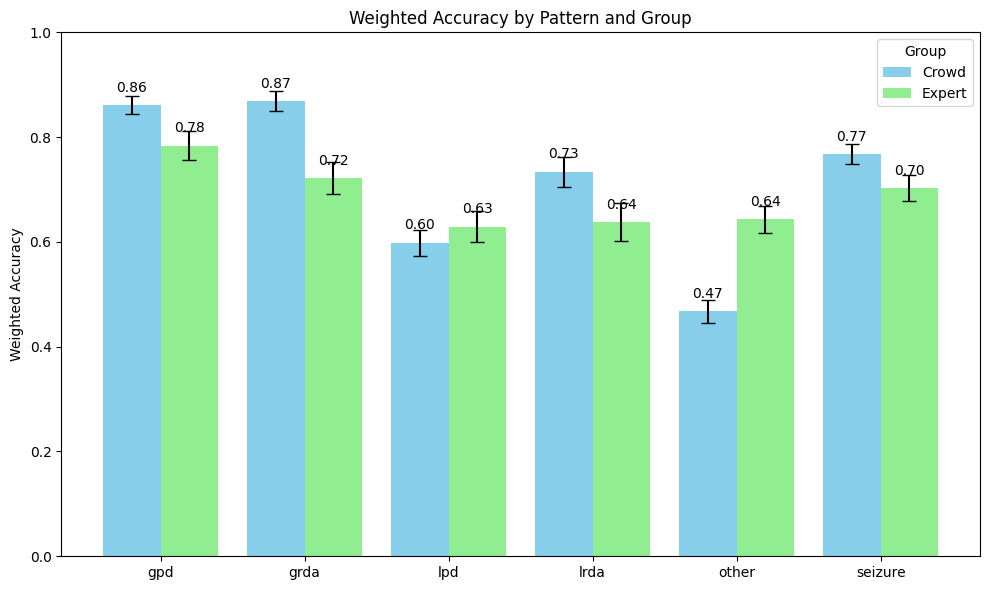

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Compute summary statistics by pattern and group.
pattern_summary = agg_df.groupby(['goldstandardnew', 'group'])['weighted_accuracy'] \
    .agg(['mean','std','count']).reset_index()
pattern_summary['se'] = pattern_summary['std'] / np.sqrt(pattern_summary['count'])
pattern_summary['ci'] = 1.96 * pattern_summary['se']

print(pattern_summary)

# Get unique patterns and groups.
patterns = pattern_summary['goldstandardnew'].unique()
groups = pattern_summary['group'].unique()

# Create a mapping from group name to a color (optional)
colors = {'Expert': 'lightgreen', 'Crowd': 'skyblue'}

# Set the positions for the grouped bars.
x = np.arange(len(patterns))  # positions for each pattern on x-axis
n_groups = len(groups)
width = 0.8 / n_groups  # total width of bars in a cluster is 0.8

fig, ax = plt.subplots(figsize=(10, 6))

# Loop over each group to plot its bars.
for i, grp in enumerate(groups):
    # Filter data for current group.
    grp_data = pattern_summary[pattern_summary['group'] == grp]
    # Ensure the data is in the same order as the patterns.
    grp_data = grp_data.set_index('goldstandardnew').loc[patterns].reset_index()

    # Calculate the position for each bar.
    pos = x - 0.4 + i*width + width/2

    bars = ax.bar(pos, grp_data['mean'], width, yerr=grp_data['ci'],
                  capsize=5, label=grp, color=colors.get(grp, None))

    # Annotate each bar with the mean accuracy value.
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}',
                ha='center', va='bottom', fontsize=10)

# Customize the plot.
ax.set_xticks(x)
ax.set_xticklabels(patterns)
ax.set_ylabel('Weighted Accuracy')
ax.set_title('Weighted Accuracy by Pattern and Group')
ax.set_ylim(0, 1)  # since accuracy is bounded between 0 and 1
ax.legend(title='Group')

plt.tight_layout()
plt.show()


<ipython-input-21-242a80ef684e>:57: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_overall_WM = df.groupby(['problem_id', 'group']).apply(
<ipython-input-21-242a80ef684e>:71: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_pattern_WM = df.groupby(['problem_id', 'group', 'goldstandardnew'], observed=True).apply(
<ipython-input-21-242a80ef684e>:92: FutureWarning: The default of observed=False is deprecat

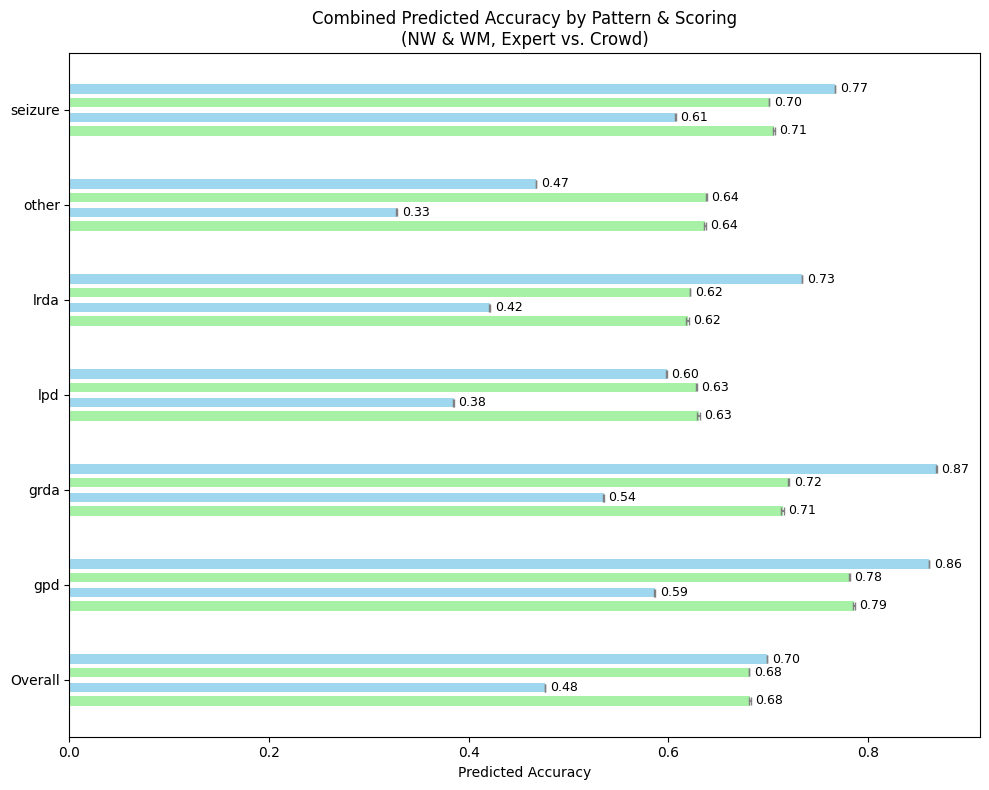

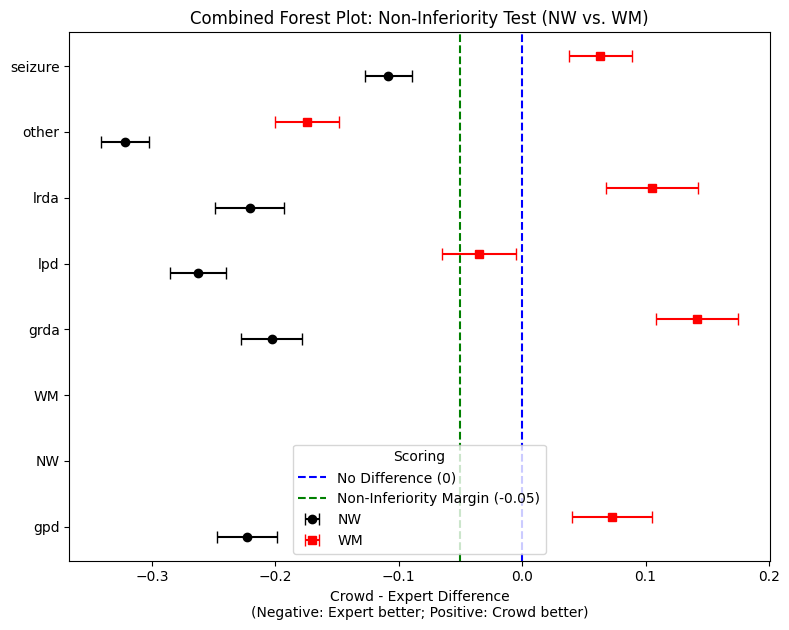

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy.stats import norm
import matplotlib.pyplot as plt

##############################################
# 1. DATA PREPARATION & MODEL FITTING
##############################################
# Assume df is already loaded with columns:
# 'user_id', 'problem_id', 'title', 'goldstandardnew', 'experience_level', 'combinedaccuracy'

# Use a single group variable, renaming all non-Expert to "Crowd"
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)
df['group'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Crowd')
df['user_question_count'] = df.groupby('user_id')['problem_id'].transform('nunique')

## -------------------------------
## Model 1: Overall, Non-Weighted
## -------------------------------
agg_overall_NW = df.groupby(['problem_id', 'group']).agg({
    'correct': ['mean', 'count'],
    'user_question_count': 'mean'
}).reset_index()
agg_overall_NW.columns = ['problem_id', 'group', 'accuracy', 'n', 'avg_question_count']
agg_overall_NW['group'] = agg_overall_NW['group'].astype('category')

model_overall_NW = smf.mixedlm("accuracy ~ group + avg_question_count", agg_overall_NW,
                               groups=agg_overall_NW["problem_id"])
result_overall_NW = model_overall_NW.fit()

## -------------------------------
## Model 2: By-Pattern, Non-Weighted
## -------------------------------
agg_pattern_NW = df.groupby(['problem_id', 'group', 'goldstandardnew'], observed=True).agg({
    'correct': 'mean',
    'user_question_count': 'mean'
}).reset_index()
agg_pattern_NW.rename(columns={'correct': 'accuracy',
                               'user_question_count': 'avg_question_count',
                               'goldstandardnew': 'pattern'}, inplace=True)
agg_pattern_NW['group'] = agg_pattern_NW['group'].astype('category')
agg_pattern_NW['pattern'] = agg_pattern_NW['pattern'].astype('category')

model_pattern_NW = smf.mixedlm("accuracy ~ group * pattern + avg_question_count", agg_pattern_NW,
                               groups=agg_pattern_NW["problem_id"])
result_pattern_NW = model_pattern_NW.fit()

## -------------------------------
## Model 3: Overall, Weighted
## -------------------------------
def compute_weighted_accuracy(sub_df):
    pred = sub_df.groupby('title')['combinedaccuracy'].sum().idxmax()
    gold = sub_df['goldstandardnew'].iloc[0]
    return int(pred == gold)

agg_overall_WM = df.groupby(['problem_id', 'group']).apply(
    lambda sub_df: pd.Series({
        'weighted_accuracy': compute_weighted_accuracy(sub_df),
        'avg_question_count': sub_df['user_question_count'].mean()
    })
).reset_index()

model_overall_WM = smf.mixedlm("weighted_accuracy ~ group + avg_question_count", agg_overall_WM,
                               groups=agg_overall_WM["problem_id"])
result_overall_WM = model_overall_WM.fit()

## -------------------------------
## Model 4: By-Pattern, Weighted
## -------------------------------
agg_pattern_WM = df.groupby(['problem_id', 'group', 'goldstandardnew'], observed=True).apply(
    lambda sub_df: pd.Series({
        'weighted_accuracy': compute_weighted_accuracy(sub_df),
        'avg_question_count': sub_df['user_question_count'].mean()
    })
).reset_index()
agg_pattern_WM.rename(columns={'goldstandardnew': 'pattern'}, inplace=True)
agg_pattern_WM['group'] = agg_pattern_WM['group'].astype('category')
agg_pattern_WM['pattern'] = agg_pattern_WM['pattern'].astype('category')

model_pattern_WM = smf.mixedlm("weighted_accuracy ~ group * pattern + avg_question_count", agg_pattern_WM,
                               groups=agg_pattern_WM["problem_id"])
result_pattern_WM = model_pattern_WM.fit()

##############################################
# 2. COMBINED BAR GRAPH: PREDICTED ACCURACY
##############################################
# For each model, compute predicted accuracy and summary stats.

# Model 1: Overall NW
agg_overall_NW['predicted_accuracy'] = result_overall_NW.predict(agg_overall_NW)
overall_NW_summary = agg_overall_NW.groupby('group')['predicted_accuracy'].agg(['mean','std','count']).reset_index()
overall_NW_summary['se'] = overall_NW_summary['std'] / np.sqrt(overall_NW_summary['count'])
overall_NW_summary['ci'] = 1.96 * overall_NW_summary['se']
overall_NW_summary['pattern'] = 'Overall'
overall_NW_summary['scoring'] = 'NW'

# Model 2: Pattern NW
agg_pattern_NW['predicted_accuracy'] = result_pattern_NW.predict(agg_pattern_NW)
pattern_NW_summary = agg_pattern_NW.groupby(['pattern', 'group'])['predicted_accuracy'].agg(['mean','std','count']).reset_index()
pattern_NW_summary['se'] = pattern_NW_summary['std'] / np.sqrt(pattern_NW_summary['count'])
pattern_NW_summary['ci'] = 1.96 * pattern_NW_summary['se']
pattern_NW_summary['scoring'] = 'NW'

# Model 3: Overall WM
agg_overall_WM['predicted_accuracy'] = result_overall_WM.predict(agg_overall_WM)
overall_WM_summary = agg_overall_WM.groupby('group')['predicted_accuracy'].agg(['mean','std','count']).reset_index()
overall_WM_summary['se'] = overall_WM_summary['std'] / np.sqrt(overall_WM_summary['count'])
overall_WM_summary['ci'] = 1.96 * overall_WM_summary['se']
overall_WM_summary['pattern'] = 'Overall'
overall_WM_summary['scoring'] = 'WM'

# Model 4: Pattern WM
agg_pattern_WM['predicted_accuracy'] = result_pattern_WM.predict(agg_pattern_WM)
pattern_WM_summary = agg_pattern_WM.groupby(['pattern', 'group'])['predicted_accuracy'].agg(['mean','std','count']).reset_index()
pattern_WM_summary['se'] = pattern_WM_summary['std'] / np.sqrt(pattern_WM_summary['count'])
pattern_WM_summary['ci'] = 1.96 * pattern_WM_summary['se']
pattern_WM_summary['scoring'] = 'WM'

# Combine all bar summaries.
bar_df = pd.concat([overall_NW_summary, pattern_NW_summary, overall_WM_summary, pattern_WM_summary], ignore_index=True)

# Order: Overall first, then patterns alphabetically.
cat_order = ['Overall'] + sorted([p for p in bar_df['pattern'].unique() if p != 'Overall'])
bar_df['pattern'] = pd.Categorical(bar_df['pattern'], categories=cat_order, ordered=True)
bar_df.sort_values('pattern', inplace=True)

# For consistent plotting, standardize group labels to "Expert" and "Crowd".
bar_df['group_std'] = bar_df['group']

# Create a horizontal grouped bar plot.
categories = cat_order
scoring_levels = ['NW', 'WM']
group_levels = ['Expert', 'Crowd']

n_cat = len(categories)
base_y = np.arange(n_cat)
# Offsets (adjust as needed)
scoring_offset = {'NW': -0.15, 'WM': 0.15}
group_offset = {'Expert': -0.07, 'Crowd': 0.07}

y_positions = []
bar_means = []
bar_cis = []
labels = []

for i, cat in enumerate(categories):
    for scoring in scoring_levels:
        for grp in group_levels:
            subset = bar_df[(bar_df['pattern'] == cat) & (bar_df['scoring'] == scoring) & (bar_df['group_std'] == grp)]
            if not subset.empty:
                mean_val = subset['mean'].values[0]
                ci_val = subset['ci'].values[0]
            else:
                mean_val = np.nan
                ci_val = np.nan
            y = base_y[i] + scoring_offset[scoring] + group_offset[grp]
            y_positions.append(y)
            bar_means.append(mean_val)
            bar_cis.append(ci_val)
            labels.append(f"{scoring}-{grp}")

y_positions = np.array(y_positions)
bar_means = np.array(bar_means)
bar_cis = np.array(bar_cis)

fig, ax = plt.subplots(figsize=(10, 8))
for i in range(len(y_positions)):
    color = 'lightgreen' if 'Expert' in labels[i] else 'skyblue'
    ax.barh(y_positions[i], bar_means[i], height=0.1, color=color, alpha=0.8)
    ax.errorbar(bar_means[i], y_positions[i], xerr=bar_cis[i], fmt='none', color='gray', capsize=3)
    ax.text(bar_means[i] + 0.005, y_positions[i], f"{bar_means[i]:.2f}", va='center', fontsize=9)
ax.set_yticks(base_y)
ax.set_yticklabels(categories)
ax.set_xlabel("Predicted Accuracy")
ax.set_title("Combined Predicted Accuracy by Pattern & Scoring\n(NW & WM, Expert vs. Crowd)")
plt.tight_layout()
plt.show()

##############################################
# 3. COMBINED FOREST PLOT: NON-INFERIORITY
##############################################
# For forest plots we extract the group effect estimates.
# Now the group coefficient key is assumed to be "group[T.Crowd]" for both NW and WM.
noninf_margin = -0.05

def extract_overall_NI(result_obj, model_label='Overall'):
    params = result_obj.params
    cov = result_obj.cov_params()
    # With Crowd as reference, the key is "group[T.Expert]" which equals (Expert – Crowd)
    coeff_key = "group[T.Expert]"
    diff_expert_vs_crowd = params[coeff_key]
    se = np.sqrt(cov.loc[coeff_key, coeff_key])
    # Convert to (Crowd - Expert)
    diff = -diff_expert_vs_crowd
    # Compute 95% CI for (Expert - Crowd)
    lower_expert = diff_expert_vs_crowd - 1.96 * se
    upper_expert = diff_expert_vs_crowd + 1.96 * se
    # Reverse CI for (Crowd - Expert)
    lower = -upper_expert
    upper = -lower_expert
    z = (diff - noninf_margin) / se
    p_val = norm.cdf(z)
    return {'pattern': model_label, 'scoring': None, 'difference': diff, 'se': se,
            'lower': lower, 'upper': upper, 'z': z, 'p': p_val}

def extract_pattern_NI(result_obj, patterns_list, model_label='NW'):
    params = result_obj.params
    cov = result_obj.cov_params()
    results = []
    # Baseline: assumed to be "gpd" (overall within pattern model)
    coeff_key = "group[T.Expert]"
    diff_expert_vs_crowd = params[coeff_key]
    se_baseline = np.sqrt(cov.loc[coeff_key, coeff_key])
    lower_expert = diff_expert_vs_crowd - 1.96 * se_baseline
    upper_expert = diff_expert_vs_crowd + 1.96 * se_baseline
    diff = -diff_expert_vs_crowd  # (Crowd - Expert)
    lower = -upper_expert
    upper = -lower_expert
    z_baseline = (diff - noninf_margin) / se_baseline
    p_baseline = norm.cdf(z_baseline)
    results.append({'pattern': 'gpd', 'scoring': model_label, 'difference': diff,
                    'se': se_baseline, 'lower': lower, 'upper': upper,
                    'z': z_baseline, 'p': p_baseline})
    for pat in patterns_list:
        term = f"group[T.Expert]:pattern[T.{pat}]"
        if term in params.index:
            diff_expert_vs_crowd = params[coeff_key] + params[term]
            var_base = cov.loc[coeff_key, coeff_key]
            var_int = cov.loc[term, term]
            covar = cov.loc[coeff_key, term]
            se_pat = np.sqrt(var_base + var_int + 2 * covar)
            lower_expert = diff_expert_vs_crowd - 1.96 * se_pat
            upper_expert = diff_expert_vs_crowd + 1.96 * se_pat
            diff = -diff_expert_vs_crowd  # (Crowd - Expert)
            lower = -upper_expert
            upper = -lower_expert
            z_pat = (diff - noninf_margin) / se_pat
            p_pat = norm.cdf(z_pat)
            results.append({'pattern': pat, 'scoring': model_label, 'difference': diff,
                            'se': se_pat, 'lower': lower, 'upper': upper, 'z': z_pat, 'p': p_pat})
    return results

# Extract NI results:
NI_overall_NW = extract_overall_NI(result_overall_NW, model_label='NW')
all_patterns_NW = sorted(agg_pattern_NW['pattern'].unique().tolist())
NI_pattern_NW = extract_pattern_NI(result_pattern_NW, [p for p in all_patterns_NW if p != 'gpd'], model_label='NW')

NI_overall_WM = extract_overall_NI(result_overall_WM, model_label='WM')
all_patterns_WM = sorted(agg_pattern_WM['pattern'].unique().tolist())
NI_pattern_WM = extract_pattern_NI(result_pattern_WM, [p for p in all_patterns_WM if p != 'gpd'], model_label='WM')

# Combine all NI results into one DataFrame.
# Wrap overall results in a list.
NI_results = pd.DataFrame([NI_overall_NW] + [NI_overall_WM] + NI_pattern_NW + NI_pattern_WM)
# Define the order for plotting; assume overall is labeled "gpd" and then other patterns alphabetically.
cat_order = ['gpd'] + sorted([p for p in NI_results['pattern'].unique() if p != 'gpd'])
NI_results['pattern'] = pd.Categorical(NI_results['pattern'], categories=cat_order, ordered=True)
NI_results.sort_values(['pattern', 'scoring'], inplace=True)

# Prepare data for forest plot.
y_base = np.arange(len(cat_order))
offset_val = 0.15
forest_list = []
for i, cat in enumerate(cat_order):
    for scoring in ['NW', 'WM']:
        row = NI_results[(NI_results['pattern'] == cat) & (NI_results['scoring'] == scoring)]
        if not row.empty:
            forest_list.append({
                'pattern': cat,
                'scoring': scoring,
                'difference': row['difference'].values[0],
                'lower': row['lower'].values[0],
                'upper': row['upper'].values[0],
                'y': i + (offset_val if scoring=='WM' else -offset_val)
            })
forest_plot_df = pd.DataFrame(forest_list)

# Create the forest plot.
fig, ax = plt.subplots(figsize=(8, len(cat_order)*0.8))
for idx, r in forest_plot_df.iterrows():
    marker = 'o' if r['scoring']=='NW' else 's'
    color = 'black' if r['scoring']=='NW' else 'red'
    ax.errorbar(r['difference'], r['y'],
                xerr=[[r['difference'] - r['lower']], [r['upper'] - r['difference']]],
                fmt=marker, capsize=4, color=color,
                label=r['scoring'] if r['y'] in [forest_plot_df['y'].min(), forest_plot_df['y'].max()] else "")
ax.axvline(x=0, color='blue', linestyle='--', label='No Difference (0)')
ax.axvline(x=noninf_margin, color='green', linestyle='--', label=f'Non-Inferiority Margin ({noninf_margin})')
ax.set_yticks(y_base)
ax.set_yticklabels(cat_order)
ax.set_xlabel("Crowd - Expert Difference\n(Negative: Expert better; Positive: Crowd better)")
ax.set_title("Combined Forest Plot: Non-Inferiority Test (NW vs. WM)")
ax.legend(title="Scoring")
plt.tight_layout()
plt.show()

Unique patterns before renaming:
['Overall', 'Seizure', 'Other', 'LRDA', 'LPD', 'GRDA', 'GPD']
Categories (7, object): ['Overall' < 'Seizure' < 'Other' < 'LRDA' < 'LPD' < 'GRDA' < 'GPD']


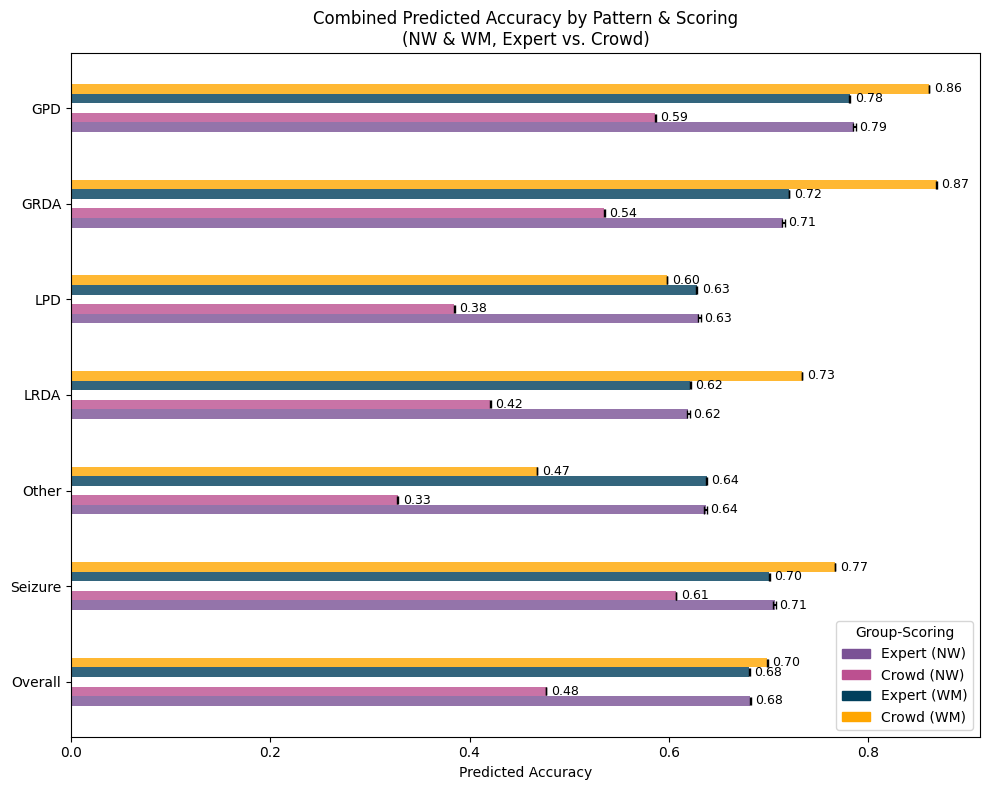

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Provided muted colors.
colors = {
    'Expert (NW)': '#7a5195',   # Light blue
    'Crowd (NW)': '#bc5090',    # Dark orange (muted)
    'Expert (WM)': '#003f5c',   # Dark blue
    'Crowd (WM)': '#ffa600'     # Light orange (muted)
}

# Print unique pattern names to check.
print("Unique patterns before renaming:")
print(bar_df['pattern'].unique())

# Renaming dictionary (adjust keys as needed)
rename_dict = {
    'gpd': 'GPD',
    'seizure': 'Seizure',
    'other': 'Other',
    'lrda': 'LRDA',
    'lpd': 'LPD',
    'grda': 'GRDA',
    'Overall': 'Overall'
}
bar_df['pattern'] = bar_df['pattern'].apply(lambda x: rename_dict.get(x, x))

# Define the order of categories for plotting.
cat_order = ['Overall', 'Seizure', 'Other', 'LRDA', 'LPD', 'GRDA', 'GPD']
bar_df['pattern'] = pd.Categorical(bar_df['pattern'], categories=cat_order, ordered=True)
bar_df.sort_values('pattern', inplace=True)

# Ensure the standardized group column is present.
bar_df['group_std'] = bar_df['group']

# For the horizontal bar plot, we want two clusters per pattern:
# one for NW and one for WM. Within each cluster, Expert and Crowd bars should be directly adjacent.
n_cat = len(cat_order)
base_y = np.arange(n_cat)
cluster_gap = 0.3   # vertical gap between NW and WM clusters

# Within each cluster, we want Expert and Crowd to be adjacent. With bar height = 0.1,
# placing one bar centered at (cluster_center - 0.05) and the other at (cluster_center + 0.05)
# means their edges exactly touch.
nw_expert_offset = -0.05
nw_crowd_offset  =  0.05
wm_expert_offset = -0.05
wm_crowd_offset  =  0.05

y_positions = []
bar_means = []
bar_cis = []
labels = []  # e.g. "NW Expert", "NW Crowd", "WM Expert", "WM Crowd"

for i, cat in enumerate(cat_order):
    # NW cluster: center = base_y[i]
    for grp, off in zip(['Expert', 'Crowd'], [nw_expert_offset, nw_crowd_offset]):
        subset = bar_df[(bar_df['pattern'] == cat) &
                        (bar_df['scoring'] == 'NW') &
                        (bar_df['group_std'] == grp)]
        if not subset.empty:
            mean_val = subset['mean'].values[0]
            ci_val = subset['ci'].values[0]
        else:
            mean_val = np.nan
            ci_val = np.nan
        y = base_y[i] + off
        y_positions.append(y)
        bar_means.append(mean_val)
        bar_cis.append(ci_val)
        labels.append(f"NW {grp}")
    # WM cluster: center = base_y[i] + cluster_gap
    for grp, off in zip(['Expert', 'Crowd'], [wm_expert_offset, wm_crowd_offset]):
        subset = bar_df[(bar_df['pattern'] == cat) &
                        (bar_df['scoring'] == 'WM') &
                        (bar_df['group_std'] == grp)]
        if not subset.empty:
            mean_val = subset['mean'].values[0]
            ci_val = subset['ci'].values[0]
        else:
            mean_val = np.nan
            ci_val = np.nan
        y = base_y[i] + cluster_gap + off
        y_positions.append(y)
        bar_means.append(mean_val)
        bar_cis.append(ci_val)
        labels.append(f"WM {grp}")

y_positions = np.array(y_positions)
bar_means = np.array(bar_means)
bar_cis = np.array(bar_cis)

# Create the horizontal bar plot.
fig, ax = plt.subplots(figsize=(10, 8))
for i in range(len(y_positions)):
    # Build the key for colors: e.g., "Expert (NW)" from label "NW Expert"
    parts = labels[i].split()
    key = f"{parts[1]} ({parts[0]})"  # e.g., "Expert (NW)" or "Crowd (WM)"
    color = colors.get(key, 'gray')
    ax.barh(y_positions[i], bar_means[i], height=0.1, color=color, alpha=0.8)
    ax.errorbar(bar_means[i], y_positions[i], xerr=bar_cis[i], fmt='none', color='black', capsize=3)
    ax.text(bar_means[i] + 0.005, y_positions[i], f"{bar_means[i]:.2f}", va='center', fontsize=9)

# Set y-axis ticks at the center of each category.
# We want to label each pattern once at the midpoint between NW and WM clusters.
ax.set_yticks(base_y + cluster_gap/2)
ax.set_yticklabels(cat_order)
ax.set_xlabel("Predicted Accuracy")
ax.set_title("Combined Predicted Accuracy by Pattern & Scoring\n(NW & WM, Expert vs. Crowd)")

# Create a custom legend.
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color=colors['Expert (NW)'], label='Expert (NW)'),
    mpatches.Patch(color=colors['Crowd (NW)'], label='Crowd (NW)'),
    mpatches.Patch(color=colors['Expert (WM)'], label='Expert (WM)'),
    mpatches.Patch(color=colors['Crowd (WM)'], label='Crowd (WM)')
]
ax.legend(handles=legend_patches, title="Group-Scoring", loc='lower right')

plt.tight_layout()
plt.show()


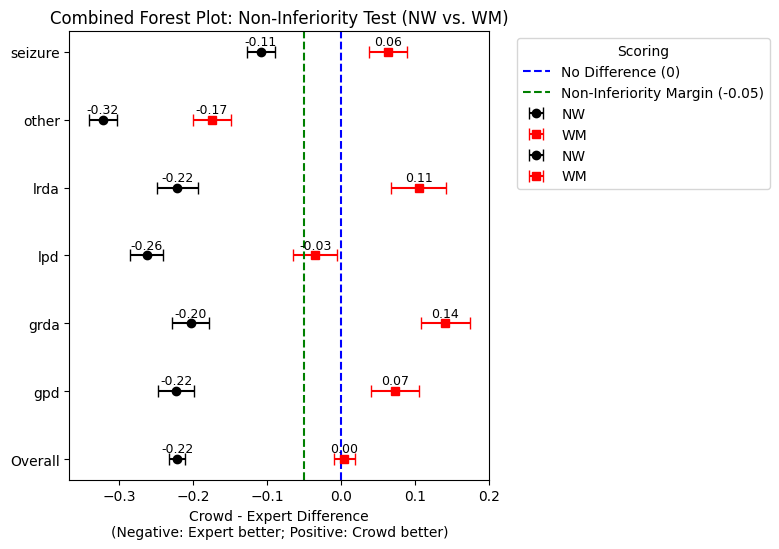

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

noninf_margin = -0.05

def extract_overall_NI(result_obj, patterns_list='Overall', model_label='NW'):
    params = result_obj.params
    cov = result_obj.cov_params()
    # With Crowd as reference, the key is "group[T.Expert]" which equals (Expert – Crowd)
    coeff_key = "group[T.Expert]"
    diff_expert_vs_crowd = params[coeff_key]
    se = np.sqrt(cov.loc[coeff_key, coeff_key])
    # Convert to (Crowd - Expert)
    diff = -diff_expert_vs_crowd
    # Compute 95% CI for (Expert - Crowd)
    lower_expert = diff_expert_vs_crowd - 1.96 * se
    upper_expert = diff_expert_vs_crowd + 1.96 * se
    # Reverse CI for (Crowd - Expert)
    lower = -upper_expert
    upper = -lower_expert
    z = (diff - noninf_margin) / se
    p_val = norm.cdf(z)
    return {'pattern': patterns_list, 'scoring': model_label, 'difference': diff, 'se': se,
            'lower': lower, 'upper': upper, 'z': z, 'p': p_val}

def extract_pattern_NI(result_obj, patterns_list, model_label='NW'):
    params = result_obj.params
    cov = result_obj.cov_params()
    results = []
    # Baseline: from the pattern model; we use the first pattern in patterns_list as the baseline label.
    coeff_key = "group[T.Expert]"
    diff_expert_vs_crowd = params[coeff_key]
    se_baseline = np.sqrt(cov.loc[coeff_key, coeff_key])
    lower_expert = diff_expert_vs_crowd - 1.96 * se_baseline
    upper_expert = diff_expert_vs_crowd + 1.96 * se_baseline
    diff = -diff_expert_vs_crowd  # (Crowd - Expert)
    lower = -upper_expert
    upper = -lower_expert
    z_baseline = (diff - noninf_margin) / se_baseline
    p_baseline = norm.cdf(z_baseline)
    baseline_pattern = patterns_list[0] if patterns_list else "Baseline"
    results.append({'pattern': baseline_pattern, 'scoring': model_label, 'difference': diff,
                    'se': se_baseline, 'lower': lower, 'upper': upper,
                    'z': z_baseline, 'p': p_baseline})
    for pat in patterns_list[1:]:
        term = f"group[T.Expert]:pattern[T.{pat}]"
        if term in params.index:
            diff_expert_vs_crowd = params[coeff_key] + params[term]
            var_base = cov.loc[coeff_key, coeff_key]
            var_int = cov.loc[term, term]
            covar = cov.loc[coeff_key, term]
            se_pat = np.sqrt(var_base + var_int + 2 * covar)
            lower_expert = diff_expert_vs_crowd - 1.96 * se_pat
            upper_expert = diff_expert_vs_crowd + 1.96 * se_pat
            diff = -diff_expert_vs_crowd  # (Crowd - Expert)
            lower = -upper_expert
            upper = -lower_expert
            z_pat = (diff - noninf_margin) / se_pat
            p_pat = norm.cdf(z_pat)
            results.append({'pattern': pat, 'scoring': model_label, 'difference': diff,
                            'se': se_pat, 'lower': lower, 'upper': upper, 'z': z_pat, 'p': p_pat})
    return results

# IMPORTANT: For overall results, use model_label="Overall" (not "NW" or "WM")
NI_overall_NW = extract_overall_NI(result_overall_NW, patterns_list='Overall', model_label='NW')
NI_overall_WM = extract_overall_NI(result_overall_WM, patterns_list='Overall', model_label='WM')

# For pattern results, we exclude "Overall" (if present) and use "NW" or "WM".
all_patterns_NW = sorted(agg_pattern_NW['pattern'].unique().tolist())
patterns_NW = [p for p in all_patterns_NW if p != "Overall"]
NI_pattern_NW = extract_pattern_NI(result_pattern_NW, patterns_NW, model_label='NW')

all_patterns_WM = sorted(agg_pattern_WM['pattern'].unique().tolist())
patterns_WM = [p for p in all_patterns_WM if p != "Overall"]
NI_pattern_WM = extract_pattern_NI(result_pattern_WM, patterns_WM, model_label='WM')

# Combine all NI results.
NI_results = pd.DataFrame([NI_overall_NW] + [NI_overall_WM] + NI_pattern_NW + NI_pattern_WM)

# Define plotting order: Overall first, then remaining patterns alphabetically.
cat_order = ['Overall'] + sorted([p for p in NI_results['pattern'].unique() if p != 'Overall'])
NI_results['pattern'] = pd.Categorical(NI_results['pattern'], categories=cat_order, ordered=True)
NI_results.sort_values(['pattern', 'scoring'], inplace=True)

y_mapping = {}
for i, cat in enumerate(cat_order):
    y_mapping[cat] = i  # now each category gets a unique y (0, 1, 2, ...)

# Prepare data for the forest plot.
forest_list = []
for cat in cat_order:
    for scoring in ['NW', 'WM']:
        row = NI_results[(NI_results['pattern'] == cat) & (NI_results['scoring'] == scoring)]
        if not row.empty:
            offset = 0.15 if scoring == 'WM' else -0.15
            forest_list.append({
                'pattern': cat,
                'scoring': scoring,
                'difference': row['difference'].values[0],
                'lower': row['lower'].values[0],
                'upper': row['upper'].values[0],
                'y': y_mapping[cat]
            })
forest_plot_df = pd.DataFrame(forest_list)

# Create the forest plot.
fig, ax = plt.subplots(figsize=(8, len(cat_order)*0.8))
for idx, r in forest_plot_df.iterrows():
    marker = 'o' if r['scoring'] == 'NW' else 's'
    # Use black for NW and red for WM.
    color = 'black' if r['scoring'] == 'NW' else 'red'
    ax.errorbar(r['difference'], r['y'],
                xerr=[[r['difference'] - r['lower']], [r['upper'] - r['difference']]],
                fmt=marker, capsize=4, color=color,
                label=r['scoring'] if r['y'] == forest_plot_df['y'].min() or r['y'] == forest_plot_df['y'].max() else "")
    # Label point estimate slightly above the marker.
    ax.text(r['difference'], r['y'] + 0.1, f"{r['difference']:.2f}", ha='center', fontsize=9)
ax.axvline(x=0, color='blue', linestyle='--', label='No Difference (0)')
ax.axvline(x=noninf_margin, color='green', linestyle='--', label=f'Non-Inferiority Margin ({noninf_margin})')
yticks = [y_mapping[cat] for cat in cat_order]
ax.set_yticks(yticks)
ax.set_yticklabels(cat_order)
ax.set_xlabel("Crowd - Expert Difference\n(Negative: Expert better; Positive: Crowd better)")
ax.set_title("Combined Forest Plot: Non-Inferiority Test (NW vs. WM)")
ax.legend(title="Scoring", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

##############################################
# PART 1: Accuracy Summary Statistics
##############################################

# --- Overall, Non-Weighted (Model 1) ---
overall_NW_stats = agg_overall_NW.groupby('group').agg(
    mean_accuracy=('accuracy','mean'),
    std_accuracy=('accuracy','std'),
    count=('accuracy','count')
).reset_index()
overall_NW_stats['se'] = overall_NW_stats['std_accuracy'] / np.sqrt(overall_NW_stats['count'])
overall_NW_stats['ci'] = 1.96 * overall_NW_stats['se']

print("=== Overall Non-Weighted Accuracy Summary ===")
print(overall_NW_stats)

# --- Overall, Weighted (Model 3) ---
# (Assumes that you computed a predicted_accuracy column in agg_overall_WM)
overall_WM_stats = agg_overall_WM.groupby('group').agg(
    mean_accuracy=('weighted_accuracy','mean'),
    std_accuracy=('weighted_accuracy','std'),
    count=('weighted_accuracy','count')
).reset_index()
overall_WM_stats['se'] = overall_WM_stats['std_accuracy'] / np.sqrt(overall_WM_stats['count'])
overall_WM_stats['ci'] = 1.96 * overall_WM_stats['se']

print("\n=== Overall Weighted Accuracy Summary ===")
print(overall_WM_stats)

# --- Pattern, Non-Weighted (Model 2) ---
pattern_NW_stats = agg_pattern_NW.groupby(['pattern','group']).agg(
    mean_accuracy=('accuracy','mean'),
    std_accuracy=('accuracy','std'),
    count=('accuracy','count')
).reset_index()
pattern_NW_stats['se'] = pattern_NW_stats['std_accuracy'] / np.sqrt(pattern_NW_stats['count'])
pattern_NW_stats['ci'] = 1.96 * pattern_NW_stats['se']

print("\n=== Pattern Non-Weighted Accuracy Summary ===")
print(pattern_NW_stats)

# --- Pattern, Weighted (Model 4) ---
pattern_WM_stats = agg_pattern_WM.groupby(['pattern','group']).agg(
    mean_accuracy=('weighted_accuracy','mean'),
    std_accuracy=('weighted_accuracy','std'),
    count=('weighted_accuracy','count')
).reset_index()
pattern_WM_stats['se'] = pattern_WM_stats['std_accuracy'] / np.sqrt(pattern_WM_stats['count'])
pattern_WM_stats['ci'] = 1.96 * pattern_WM_stats['se']

print("\n=== Pattern Weighted Accuracy Summary ===")
print(pattern_WM_stats)

##############################################
# PART 2: Non-Inferiority Test Results
##############################################

# For overall models, we use the coefficient "group[T.Expert]" which (with Crowd as reference)
# equals Expert – Crowd. The null hypothesis is: Expert – Crowd > 0.05.
# We'll print the point estimate, 95% CI, and one-sided NI p-value.

print("\n=== Overall Non-Weighted NI Test (Expert - Crowd) ===")
diff_NW_overall = result_overall_NW.params["group[T.Expert]"]
se_NW_overall = np.sqrt(result_overall_NW.cov_params().loc["group[T.Expert]", "group[T.Expert]"])
ci_NW_overall = (diff_NW_overall - 1.96 * se_NW_overall, diff_NW_overall + 1.96 * se_NW_overall)
z_NW_overall = (diff_NW_overall - 0.05) / se_NW_overall
p_NW_overall = norm.cdf(z_NW_overall)
print("Expert - Crowd difference (NW overall): {:.3f}".format(diff_NW_overall))
print("95% CI: [{:.3f}, {:.3f}]".format(ci_NW_overall[0], ci_NW_overall[1]))
print("Non-inferiority p-value (NW overall): {:.4f}".format(p_NW_overall))

print("\n=== Overall Weighted NI Test (Expert - Crowd) ===")
diff_WM_overall = result_overall_WM.params["group[T.Expert]"]
se_WM_overall = np.sqrt(result_overall_WM.cov_params().loc["group[T.Expert]", "group[T.Expert]"])
ci_WM_overall = (diff_WM_overall - 1.96 * se_WM_overall, diff_WM_overall + 1.96 * se_WM_overall)
z_WM_overall = (diff_WM_overall - 0.05) / se_WM_overall
p_WM_overall = norm.cdf(z_WM_overall)
print("Expert - Crowd difference (WM overall): {:.3f}".format(diff_WM_overall))
print("95% CI: [{:.3f}, {:.3f}]".format(ci_WM_overall[0], ci_WM_overall[1]))
print("Non-inferiority p-value (WM overall): {:.4f}".format(p_WM_overall))

# For pattern models, we need to extract the NI estimates.
# We'll use extraction functions that compute (Crowd - Expert) differences.
# (Note: our extraction functions below produce (Crowd - Expert) values.)
def extract_overall_NI_model(result_obj, model_label='Overall'):
    params = result_obj.params
    cov = result_obj.cov_params()
    coeff_key = "group[T.Expert]"
    diff_expert_vs_crowd = params[coeff_key]
    se = np.sqrt(cov.loc[coeff_key, coeff_key])
    # For pattern NI, we want expert - crowd difference, so leave as is.
    return {'pattern': model_label, 'scoring': None, 'diff_expert_minus_crowd': diff_expert_vs_crowd,
            'se': se, 'lower': diff_expert_vs_crowd - 1.96 * se,
            'upper': diff_expert_vs_crowd + 1.96 * se}

# For pattern models, we need to extract the NI estimates (expert - crowd) for each pattern.
def extract_pattern_NI_model(result_obj, patterns_list, model_label='NW'):
    params = result_obj.params
    cov = result_obj.cov_params()
    results = []
    coeff_key = "group[T.Expert]"
    base_diff = params[coeff_key]
    base_se = np.sqrt(cov.loc[coeff_key, coeff_key])
    results.append({'pattern': patterns_list[0] if patterns_list else "Baseline", 'scoring': model_label,
                    'diff_expert_minus_crowd': base_diff,
                    'se': base_se,
                    'lower': base_diff - 1.96 * base_se,
                    'upper': base_diff + 1.96 * base_se})
    for pat in patterns_list[1:]:
        term = f"group[T.Expert]:pattern[T.{pat}]"
        if term in params.index:
            diff = params[coeff_key] + params[term]
            se_pat = np.sqrt(cov.loc[coeff_key, coeff_key] + cov.loc[term, term] + 2 * cov.loc[coeff_key, term])
            results.append({'pattern': pat, 'scoring': model_label,
                            'diff_expert_minus_crowd': diff,
                            'se': se_pat,
                            'lower': diff - 1.96 * se_pat,
                            'upper': diff + 1.96 * se_pat})
    return results

# Extract pattern NI results (for NW and WM), without overall.
all_patterns_NW = sorted(agg_pattern_NW['pattern'].unique().tolist())
patterns_NW = [p for p in all_patterns_NW if p != "Overall"]
NI_pattern_NW_model = extract_pattern_NI_model(result_pattern_NW, patterns_NW, model_label='NW')

all_patterns_WM = sorted(agg_pattern_WM['pattern'].unique().tolist())
patterns_WM = [p for p in all_patterns_WM if p != "Overall"]
NI_pattern_WM_model = extract_pattern_NI_model(result_pattern_WM, patterns_WM, model_label='WM')

# Convert pattern NI results to DataFrames and apply Bonferroni correction.
NI_pattern_NW_df = pd.DataFrame(NI_pattern_NW_model)
reject, pvals_corr_NW, _, _ = multipletests(NI_pattern_NW_df['p'] if 'p' in NI_pattern_NW_df.columns else NI_pattern_NW_df['diff_expert_minus_crowd'],
                                            alpha=0.05, method='bonferroni')
# Here, our extraction function did not compute p-values; if desired, compute them:
NI_pattern_NW_df['z'] = (NI_pattern_NW_df['diff_expert_minus_crowd'] - 0.05) / NI_pattern_NW_df['se']
NI_pattern_NW_df['p'] = norm.cdf(NI_pattern_NW_df['z'])
reject, pvals_corr_NW, _, _ = multipletests(NI_pattern_NW_df['p'], alpha=0.05, method='bonferroni')
NI_pattern_NW_df['p_adj'] = pvals_corr_NW

NI_pattern_WM_df = pd.DataFrame(NI_pattern_WM_model)
NI_pattern_WM_df['z'] = (NI_pattern_WM_df['diff_expert_minus_crowd'] - 0.05) / NI_pattern_WM_df['se']
NI_pattern_WM_df['p'] = norm.cdf(NI_pattern_WM_df['z'])
reject, pvals_corr_WM, _, _ = multipletests(NI_pattern_WM_df['p'], alpha=0.05, method='bonferroni')
NI_pattern_WM_df['p_adj'] = pvals_corr_WM

print("\n=== Overall NI Test (Non-Weighted) ===")
print("Expert - Crowd difference (NW overall): {:.3f}".format(diff_NW_overall))
print("95% CI: [{:.3f}, {:.3f}]".format(ci_NW_overall[0], ci_NW_overall[1]))
print("Non-inferiority p-value (NW overall): {:.4f}".format(p_NW_overall))

print("\n=== Overall NI Test (Weighted) ===")
print("Expert - Crowd difference (WM overall): {:.3f}".format(diff_WM_overall))
print("95% CI: [{:.3f}, {:.3f}]".format(ci_WM_overall[0], ci_WM_overall[1]))
print("Non-inferiority p-value (WM overall): {:.4f}".format(p_WM_overall))

print("\n=== Pattern NI Tests (Non-Weighted, Bonferroni corrected) ===")
print(NI_pattern_NW_df[['pattern', 'diff_expert_minus_crowd', 'lower', 'upper', 'p', 'p_adj']])
print("\n=== Pattern NI Tests (Weighted, Bonferroni corrected) ===")
print(NI_pattern_WM_df[['pattern', 'diff_expert_minus_crowd', 'lower', 'upper', 'p', 'p_adj']])


=== Overall Non-Weighted Accuracy Summary ===
    group  mean_accuracy  std_accuracy  count        se        ci
0   Crowd       0.476589      0.254395   8894  0.002697  0.005287
1  Expert       0.682511      0.440258   5881  0.005741  0.011252

=== Overall Weighted Accuracy Summary ===
    group  mean_accuracy  std_accuracy  count        se        ci
0   Crowd       0.698898      0.458763   8894  0.004865  0.009534
1  Expert       0.684237      0.464858   5881  0.006062  0.011881

=== Pattern Non-Weighted Accuracy Summary ===
    pattern   group  mean_accuracy  std_accuracy  count        se        ci
0       gpd   Crowd       0.586532      0.203005   1420  0.005387  0.010559
1       gpd  Expert       0.786543      0.389334    836  0.013465  0.026392
2      grda   Crowd       0.535198      0.165914   1242  0.004708  0.009227
3      grda  Expert       0.715915      0.422328    820  0.014748  0.028907
4       lpd   Crowd       0.384792      0.195742   1511  0.005036  0.009870
5       lpd 

<ipython-input-57-0b04dacfa779>:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overall_NW_stats = agg_overall_NW.groupby('group').agg(
<ipython-input-57-0b04dacfa779>:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pattern_NW_stats = agg_pattern_NW.groupby(['pattern','group']).agg(
<ipython-input-57-0b04dacfa779>:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pattern_WM_stats = agg_pattern_WM.groupby(['pattern','

In [ ]:
# Print Model 1: Overall Non-Weighted
print("Model 1: Overall Non-Weighted Summary:")
print(result_overall_NW.summary())
print("\nModel 1 Parameters:")
print(result_overall_NW.params)

# Print Model 3: Overall Weighted
print("\nModel 3: Overall Weighted Summary:")
print(result_overall_WM.summary())
print("\nModel 3 Parameters:")
print(result_overall_WM.params)


Model 1: Overall Non-Weighted Summary:
           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  accuracy  
No. Observations:   14775    Method:              REML      
No. Groups:         8894     Scale:               0.0704    
Min. group size:    1        Log-Likelihood:      -4505.5172
Max. group size:    2        Converged:           Yes       
Mean group size:    1.7                                     
------------------------------------------------------------
                   Coef. Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          0.422    0.010 41.737 0.000  0.402  0.442
group[T.Expert]    0.221    0.005 41.457 0.000  0.211  0.232
avg_question_count 0.000    0.000  5.791 0.000  0.000  0.000
Group Var          0.044    0.007                           


Model 1 Parameters:
Intercept             0.421869
group[T.Expert]       0.221235
avg_question_count    0.000014
Grou

Model Overall WM parameter names:
['Intercept', 'group[T.Expert]', 'avg_question_count', 'Group Var']
Overall Non-Inferiority Test (Weighted Scoring):
  Expert - Crowd (model coefficient): -0.004
  Converted to Crowd - Expert: 0.004
  Standard Error: 0.007
  95% CI for (Crowd - Expert): [-0.010, 0.018]
  Z-statistic: 7.585
  One-sided non-inferiority p-value: 1.0000


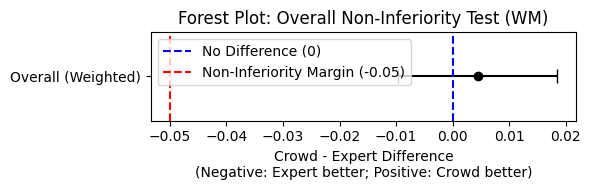

In [ ]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

# Print the parameter names for debugging.
print("Model Overall WM parameter names:")
print(result_overall_WM.params.index.tolist())

# Extract the coefficient: group[T.Expert] is (Expert - Crowd).
diff_expert_vs_crowd = result_overall_WM.params["group[T.Expert]"]
se_diff = np.sqrt(result_overall_WM.cov_params().loc["group[T.Expert]", "group[T.Expert]"])

# Convert to (Crowd - Expert) by multiplying by -1.
diff_crowd_vs_expert = -diff_expert_vs_crowd
# Compute the 95% CI for (Expert - Crowd)
lower_expert = diff_expert_vs_crowd - 1.96 * se_diff
upper_expert = diff_expert_vs_crowd + 1.96 * se_diff
# Convert CI to (Crowd - Expert)
lower_crowd = -upper_expert
upper_crowd = -lower_expert

# Set non-inferiority margin for (Crowd - Expert)
noninf_margin = -0.05

# Compute z statistic and one-sided p-value for non-inferiority:
z = (diff_crowd_vs_expert - noninf_margin) / se_diff
p_value = norm.cdf(z)

print("Overall Non-Inferiority Test (Weighted Scoring):")
print(f"  Expert - Crowd (model coefficient): {diff_expert_vs_crowd:.3f}")
print(f"  Converted to Crowd - Expert: {diff_crowd_vs_expert:.3f}")
print(f"  Standard Error: {se_diff:.3f}")
print(f"  95% CI for (Crowd - Expert): [{lower_crowd:.3f}, {upper_crowd:.3f}]")
print(f"  Z-statistic: {z:.3f}")
print(f"  One-sided non-inferiority p-value: {p_value:.4f}")

# Create a forest plot for the overall effect.
fig, ax = plt.subplots(figsize=(6, 2))
ax.errorbar(diff_crowd_vs_expert, 0,
            xerr=[[diff_crowd_vs_expert - lower_crowd], [upper_crowd - diff_crowd_vs_expert]],
            fmt='o', color='black', capsize=5)

# Plot vertical reference lines:
ax.axvline(x=0, color='blue', linestyle='--', label='No Difference (0)')
ax.axvline(x=noninf_margin, color='red', linestyle='--',
           label=f'Non-Inferiority Margin ({noninf_margin})')

ax.set_yticks([0])
ax.set_yticklabels(['Overall (Weighted)'])
ax.set_xlabel("Crowd - Expert Difference\n(Negative: Expert better; Positive: Crowd better)")
ax.set_title("Forest Plot: Overall Non-Inferiority Test (WM)")
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# Drop rows missing any of the critical columns.
df = df.dropna(subset=['user_id', 'problem_id', 'title', 'goldstandardnew', 'experience_level', 'preferred_specialty'])

# Create a new column to stratify preferred specialty: "Neurology" or "Others"
df['preferred_specialty_group'] = df['preferred_specialty'].apply(
    lambda x: 'Neurology' if 'neurology' in x.lower() else 'Others'
)

# Group by experience_level and preferred_specialty_group, and compute:
#   - unique_users: number of unique users (based on user_id)
#   - total_questions_answered: count of responses (title)
specialty_summary = df.groupby(['experience_level', 'preferred_specialty_group']).agg(
    unique_users=('user_id', 'nunique'),
    total_questions_answered=('title', 'count')
).reset_index()

print(specialty_summary)

# Also, compute overall totals across all experience levels and specialty groups.
total_unique_users = df['user_id'].nunique()
total_questions_answered = df['title'].count()

print(f"Total Unique Users: {total_unique_users}")
print(f"Total Questions Answered: {total_questions_answered}")


            experience_level preferred_specialty_group  unique_users  \
0                         DO                    Others             4   
1                     Expert                    Others             8   
2                         MD                 Neurology             3   
3                         MD                    Others            67   
4            Medical Student                 Neurology            28   
5            Medical Student                    Others           476   
6                         NP                 Neurology             2   
7                         NP                    Others            43   
8                 NP Student                    Others            30   
9                      Other                 Neurology            30   
10                     Other                    Others           413   
11  Other Healthcare Student                 Neurology            21   
12  Other Healthcare Student                    Others          

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

# Assume df is your DataFrame with columns:
# 'user_id', 'problem_id', 'title' (user answer), 'goldstandardnew' (correct answer),
# 'experience_level', 'preferred_specialty'

# Drop rows missing critical data.
df = df.dropna(subset=['user_id', 'problem_id', 'title', 'goldstandardnew', 'experience_level', 'preferred_specialty'])

# Create a binary indicator for correctness.
df['correct'] = (df['title'] == df['goldstandardnew']).astype(int)

# Create a group variable: "Expert" if experience_level is 'Expert', otherwise "Crowd".
df['group'] = df['experience_level'].apply(lambda x: 'Expert' if x == 'Expert' else 'Crowd')

# Create a composite variable combining experience_level and preferred_specialty.
# For non-experts, label as "MD Neurology", "MD Others", etc.
# For experts, assign a constant value (e.g. "Expert").
def combine_experience_specialty(row):
    if row['group'] == 'Expert':
        return 'Expert'
    else:
        specialty = 'Neurology' if 'neurology' in row['preferred_specialty'].lower() else 'Others'
        return f"{row['experience_level']} {specialty}"

df['exp_spec'] = df.apply(combine_experience_specialty, axis=1)
df['exp_spec'] = df['exp_spec'].astype('category')

# Compute the number of unique questions answered per user.
df['user_question_count'] = df.groupby('user_id')['problem_id'].transform('nunique')

# Aggregate the data by problem_id and exp_spec.
# For each group, compute the accuracy (mean of the 'correct' indicator)
# and the average number of questions answered by users in that group.
agg_df = df.groupby(['problem_id', 'exp_spec'], observed=True, group_keys=False).agg({
    'correct': 'mean',
    'user_question_count': 'mean'
}).reset_index()
agg_df.rename(columns={'correct': 'accuracy', 'user_question_count': 'avg_question_count'}, inplace=True)

# Ensure that 'exp_spec' has 'Expert' as the first (reference) category
# Get current categories
current_levels = df['exp_spec'].cat.categories.tolist()
# Create new order with 'Expert' first
new_order = ['Expert'] + [lvl for lvl in current_levels if lvl != 'Expert']
# Reorder the categories (make sure ordered=True)
df['exp_spec'] = df['exp_spec'].cat.reorder_categories(new_order, ordered=True)

# Also apply the same order when aggregating
agg_df['exp_spec'] = agg_df['exp_spec'].cat.reorder_categories(new_order, ordered=True)

# Fit the mixed-effects model
model = smf.mixedlm("accuracy ~ exp_spec + avg_question_count", agg_df, groups=agg_df["problem_id"])
result = model.fit()

print(result.summary())



                          Mixed Linear Model Regression Results
Model:                       MixedLM            Dependent Variable:            accuracy   
No. Observations:            69782              Method:                        REML       
No. Groups:                  8894               Scale:                         0.0829     
Min. group size:             4                  Log-Likelihood:                -20288.1521
Max. group size:             17                 Converged:                     Yes        
Mean group size:             7.8                                                          
------------------------------------------------------------------------------------------
                                               Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------------------------------
Intercept                                       0.577    0.005 106.112 0.000  0.566  0.587
exp_spec[T.DO Others]     

Adjusted Subgroup Differences (Expert - Crowd) with Bonferroni Correction:
                        subgroup_clean  difference     lower     upper  \
0                                   DO   -0.355925 -0.400595 -0.311254   
1                         MD Neurology   -0.208782 -0.232125 -0.185438   
2                                   MD   -0.264942 -0.277008 -0.252875   
3            Medical Student Neurology   -0.258940 -0.271989 -0.245891   
4                      Medical Student   -0.217525 -0.227527 -0.207522   
5                         NP Neurology   -0.233819 -0.256957 -0.210681   
6                                   NP   -0.224092 -0.234617 -0.213567   
7                           NP Student   -0.335036 -0.353278 -0.316794   
8   Other Healthcare Student Neurology   -0.303891 -0.321433 -0.286350   
9             Other Healthcare Student   -0.256887 -0.266677 -0.247096   
10                     Other Neurology   -0.301239 -0.316447 -0.286031   
11                               Othe

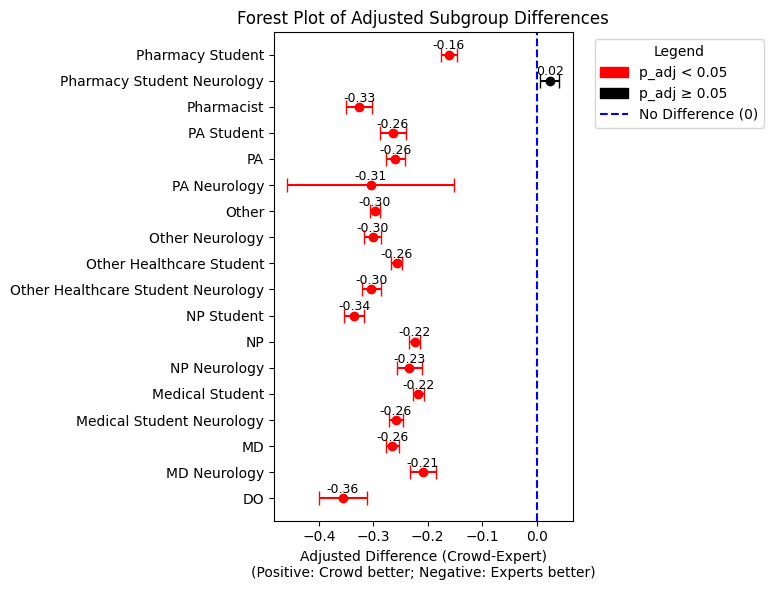

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# --- Extraction of subgroup coefficients from Model 1 (Expert is reference) ---
coef_series = result.params.filter(like="exp_spec[T.")
df_coef = pd.DataFrame({'subgroup': coef_series.index, 'coef': coef_series.values})

# Compute standard errors.
df_coef['se'] = df_coef['subgroup'].apply(lambda x: np.sqrt(result.cov_params().loc[x, x]))

# Compute 95% confidence intervals.
df_coef['lower'] = df_coef['coef'] - 1.96 * df_coef['se']
df_coef['upper'] = df_coef['coef'] + 1.96 * df_coef['se']

# Compute z-scores and raw p-values.
df_coef['z'] = df_coef['coef'] / df_coef['se']
df_coef['p_raw'] = result.pvalues.filter(like="exp_spec[T.").values

# Apply Bonferroni correction.
reject, pvals_corr, _, _ = multipletests(df_coef['p_raw'], alpha=0.05, method='bonferroni')
df_coef['p_adj'] = pvals_corr

# Clean subgroup names: remove prefix/suffix and trailing " Others"
df_coef['subgroup_clean'] = (df_coef['subgroup']
                             .str.replace("exp_spec\\[T\\.", "", regex=True)
                             .str.replace("\\]", "", regex=True)
                             .str.replace(" Others$", "", regex=True))

# Create the column for the adjusted difference.
# (Note: positive values indicate experts performed better than the crowd,
#  while negative values indicate the crowd outperformed experts.)
df_coef['difference'] = df_coef['coef']

# *** Uncomment the next line to sort by difference (highest to lowest) if desired ***
# df_coef = df_coef.sort_values('difference', ascending=False)

# Print the adjusted subgroup differences.
print("Adjusted Subgroup Differences (Expert - Crowd) with Bonferroni Correction:")
print(df_coef[['subgroup_clean', 'difference', 'lower', 'upper', 'p_raw', 'p_adj']])

# --- Create the Forest Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
# Using np.arange ensures the y-axis follows the order from the DataFrame (matching your printed table)
y_pos = np.arange(len(df_coef))

# Plot error bars and markers for each subgroup.
for i, row in df_coef.iterrows():
    # Choose marker color based on significance.
    color = 'red' if row['p_adj'] < 0.05 else 'black'
    ax.errorbar(
        row['difference'], y_pos[i],
        xerr=[[row['difference'] - row['lower']], [row['upper'] - row['difference']]],
        fmt='o', color=color, capsize=5
    )
    # Annotate the actual difference in black a bit above the marker.
    ax.text(
        row['difference'], y_pos[i] + 0.2, f"{row['difference']:.2f}",
        ha='center', fontsize=9, color='black'
    )


# Add a vertical dashed line at 0 (indicating no difference).
ax.axvline(x=0, color='blue', linestyle='--', label='No Difference (0)')

# Set the y-axis ticks and labels based on the original order.
ax.set_yticks(y_pos)
ax.set_yticklabels(df_coef['subgroup_clean'])
ax.set_xlabel("Adjusted Difference (Crowd-Expert)\n(Positive: Crowd better; Negative: Experts better)")
ax.set_title("Forest Plot of Adjusted Subgroup Differences")

# Create a custom legend.
import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='red', label='p_adj < 0.05')
black_patch = mpatches.Patch(color='black', label='p_adj ≥ 0.05')
blue_line = plt.Line2D([0], [0], color='blue', linestyle='--', label='No Difference (0)')
ax.legend(handles=[red_patch, black_patch, blue_line], title="Legend", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
